# Caso Titanic - Cristian Juble
**1. Problema:** ¿Que factores influyeron en la supervivencia de los pasajeros del titanic?

In [1]:
#importamos librerias

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2.** Cargamos los datos desde drive hacia un ***Data Frame***

In [3]:
df = pd.read_csv('./drive/MyDrive//Mineria de datos/EDATitanic/Titanic01.csv')

1. **PassengerId:** Clave unica asosiada a cada pasajero
2. **Survived:** Indica si una persona sobrevibio o no
3. **Pclass:** La clase en la que viajo cada pasajero
4. **Name:** El nombre del Pasajero
5. **Sex:** Genero del pasajero
6. **Age:** Edad del pasajero
7. **SibSP:** numeros de hermanoy o conyuge que viajaban con el pasajero
8. **Parch:** Numero de padres o hijos que viajaban con el pasajero
9. **Ticket:** El numero del boleto
10. **Fare:** La tarifa pagada por el boleto
11. **Cabin:** El nummero de compartimento donde se alojo el pasajero
12. **Embarked:** Donde el pasajero abordo el Titanic

In [ ]:
# Obtenner cantidad de registros del dataframe + Cantidad de columnas
print("[Filas,Columnas]: ",df.shape)

[Filas,Columnas]:  (891, 12)


In [ ]:
# Cantidad de registros totales por columna y el tipo de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Primeros registros del DataFrame
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Numero de valores unicos por columna
unique_values = {col: df[col].nunique() for col in df.columns}
unique_values_df = pd.DataFrame(list(unique_values.items()), columns=['Columna','Numero de valores unicos'])
display(unique_values_df)

,Columna,Numero de valores unicos
0,PassengerId,891
1,Survived,2
2,Pclass,3
3,Name,891
4,Sex,2
5,Age,88
6,SibSp,7
7,Parch,7
8,Ticket,681
9,Fare,248


In [ ]:
# Valores unicos por columna
for col in df.columns:
    unique_values = df[col].unique()
    print(f"Valores unicos en la columna '{col}':")
    print(unique_values)
    print()

Valores unicos en la columna 'PassengerId':
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 23

## Tabla Numero 1
| Variable    | Tipo de datos | Clasificacion   | Subclasificacion | Valores | Cantidad de valores | Interpretacion de origen                       |
|-------------|---------------|-----------------|------------------|---------|--------------|----------------------------------|
| PassengerId | int64         | Cualitativo     | Nominal    | 1,2,3... | 891 |Identificador único del pasajero              |
| Survived    | int64         | Cualitativo     | Nominal    | 0,1 | 2 | 0 = No Sobrevivió, 1 = Sobrevivió             |
| Pclass      | int64         | Cualitativo     | Ordinal    | 1,2,3 | 3 | 1 = Primera Clase, 2 = Segunda Clase, 3 = Tercera Clase |
| Name        | object        | Cualitativo     | Nominal    | Braund, Mr. Owen...| 891 | Nombre del pasajero                           |
| Sex         | object        | Cualitativo     | Nominal    | male, female | 2 | Género del pasajero (male/female)            |
| Age         | float64       | Cuantitativo    | Continuo   | 22,38,26... | 88 | Edad del pasajero                             |
| SibSp       | int64         | Cuantitativo    | Discreto   | 1 0 3 4 2 5 8 | 7 | Número de hermanos/cónyuges a bordo         |
| Parch       | int64         | Cuantitativo    | Discreto   | 0 1 2 5 3 4 6 | 7 | Número de padres/hijos a bordo               |
| Ticket      | object        | Cualitativo     | Nominal    | A/5 21171, PC... | 681 | Número de ticket                             |
| Fare        | float64       | Cuantitativo    | Continuo   | 7.25, 71.2833... | 248 | Tarifa pagada por el pasajero                |
| Cabin       | object        | Cualitativo     | Nominal    | C85, C123... | 147 | Número de cabina                             |
| Embarked    | object        | Cualitativo     | Nominal    | S, C, Q | 3 | Puerto de embarque (C, Q, S)                 |

## Tabla Numero 2
| Variable    | Tipo de datos | Clasificacion   | Subclasificacion | Cantidad de registros con valores | Cantidad de valores unicos | Cantidad de nulos    |
|-------------|---------------|-----------------|------------------|---------|--------------|----------------------------------|
| PassengerId | int64         | Cualitativo     | Nominal    | 891 | 891 | 0 |
| Survived    | int64         | Cualitativo     | Nominal    | 891 | 2 | 0 |
| Pclass      | int64         | Cualitativo     | Ordinal    | 891 | 3 | 0 |
| Name        | object        | Cualitativo     | Nominal    | 891 | 891 | 0 |
| Sex         | object        | Cualitativo     | Nominal    | 891 | 2 | 0 |
| Age         | float64       | Cuantitativo    | Continuo   | 714 | 88 | 177 |
| SibSp       | int64         | Cuantitativo    | Discreto   | 891 | 7 | 0 |
| Parch       | int64         | Cuantitativo    | Discreto   | 891 | 7 | 0 |
| Ticket      | object        | Cualitativo     | Nominal    | 891 | 681 | 0 |
| Fare        | float64       | Cuantitativo    | Continuo   | 891 | 248 | 0 |
| Cabin       | object        | Cualitativo     | Nominal    | 204 | 147 | 687 |
| Embarked    | object        | Cualitativo     | Nominal    | 889 | 3 | 2 |

## Histogramas

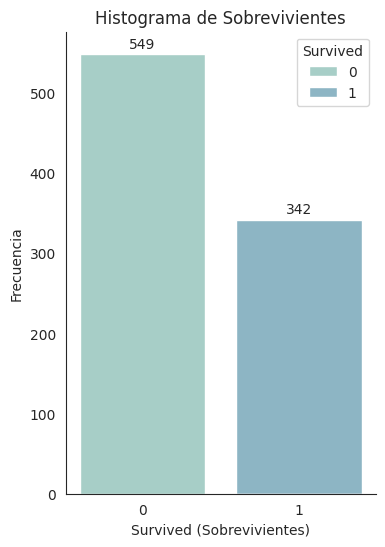


Porcentajes de sobrevibientes
---------------------------------
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64
---------------------------------
0 - No sobrevivio
1 - Si sobrevivio


In [ ]:
sns.set_style("white")
# Histograma Sobrevivientes
plt.figure(figsize=(4, 6))
ax = sns.histplot(data=df, x='Survived', hue='Survived', palette='crest',discrete=True, shrink=.8)
plt.xticks([0, 1])
plt.title('Histograma de Sobrevivientes')
plt.xlabel('Survived (Sobrevivientes)')
plt.ylabel('Frecuencia')
for container in ax.containers:
    ax.bar_label(container, padding=2, fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
sns.despine()
plt.show()

print()
print("Porcentajes de sobrevibientes")
print("-"*33)
print(df['Survived'].value_counts(normalize=True) * 100)
print("-"*33)
print("0 - No sobrevivio")
print("1 - Si sobrevivio")

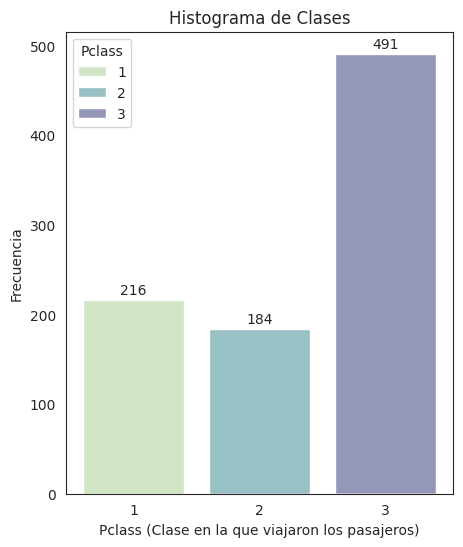


Porcentaje de pasajeros que viajaron en cada clase
--------------------------------------------------
Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64
--------------------------------------------------
1 - Primera Clase
2 - Segunda Clase
3 - Tercera Clase


In [ ]:
# Histograma Clase en la que viajaron los pasajeros
plt.figure(figsize=(5, 6))
ax = sns.histplot(data=df, x='Pclass', hue='Pclass', palette='crest',discrete=True, shrink=.8)
plt.xticks([1,2,3])
plt.title('Histograma de Clases')
plt.xlabel('Pclass (Clase en la que viajaron los pasajeros)')
plt.ylabel('Frecuencia')
for container in ax.containers:
    ax.bar_label(container, padding=2, fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
plt.show()

print()
print("Porcentaje de pasajeros que viajaron en cada clase")
print("-"*50)
print(df['Pclass'].value_counts(normalize=True) * 100)
print("-"*50)
print("1 - Primera Clase")
print("2 - Segunda Clase")
print("3 - Tercera Clase")

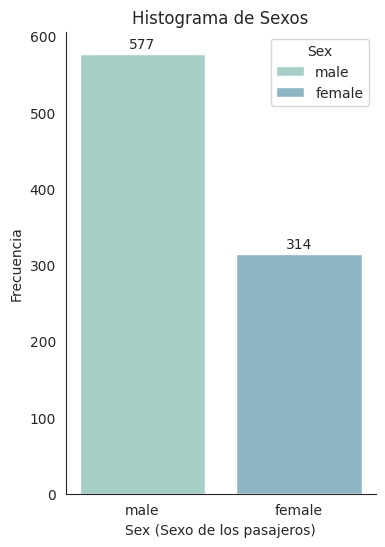


Porcentaje de pasajeros de cada sexo
-------------------------------------
Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64
-------------------------------------
male - Hombres
female - Mujeres


In [ ]:
# Histograma Sexo de los pasajeros
plt.figure(figsize=(4, 6))
ax = sns.histplot(data=df, x='Sex', hue='Sex', palette='crest', shrink=.8)
plt.title('Histograma de Sexos')
plt.xlabel('Sex (Sexo de los pasajeros)')
plt.ylabel('Frecuencia')
for container in ax.containers:
    ax.bar_label(container, padding=2, fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
sns.despine()
plt.show()

print()
print("Porcentaje de pasajeros de cada sexo")
print("-"*37)
print(df['Sex'].value_counts(normalize=True) * 100)
print("-"*37)
print("male - Hombres")
print("female - Mujeres")

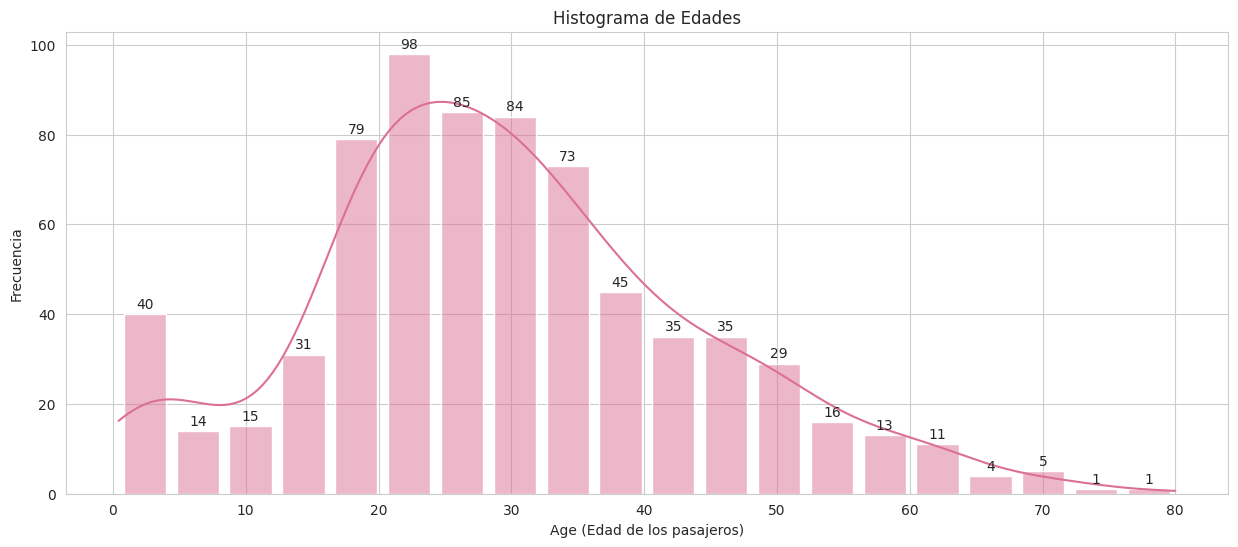

In [ ]:
sns.set_style("whitegrid")
# Histograma de Edades
plt.figure(figsize=(15, 6))
ax = sns.histplot(data=df, x='Age', color='palevioletred', kde=True, shrink=.8)
plt.title('Histograma de Edades')
plt.xlabel('Age (Edad de los pasajeros)')
plt.ylabel('Frecuencia')
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.show()

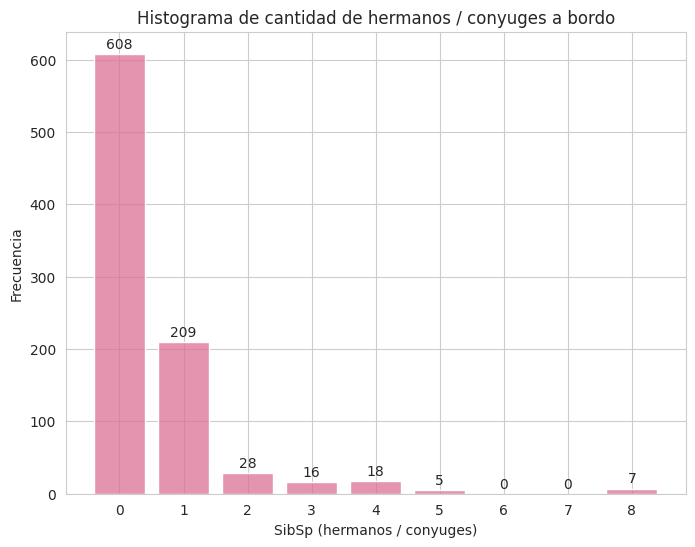


Porcentaje de cantidad de hermanos o conyuges a bordo
-------------------------------------------------------
SibSp
0    68.237935
1    23.456790
2     3.142536
4     2.020202
3     1.795735
8     0.785634
5     0.561167
Name: proportion, dtype: float64
-------------------------------------------------------


In [ ]:
sns.set_style("whitegrid")
# Histograma de cantidad de hermanos / conyuges a bordo
plt.figure(figsize=(8, 6))
ax = sns.histplot(data=df, x='SibSp', color='palevioletred',discrete=True, shrink=.8)
plt.xticks([0,1,2,3,4,5,6,7,8])
plt.title('Histograma de cantidad de hermanos / conyuges a bordo')
plt.xlabel('SibSp (hermanos / conyuges)')
plt.ylabel('Frecuencia')
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.show()

print()
print("Porcentaje de cantidad de hermanos o conyuges a bordo")
print("-"*55)
print(df['SibSp'].value_counts(normalize=True) * 100)
print("-"*55)

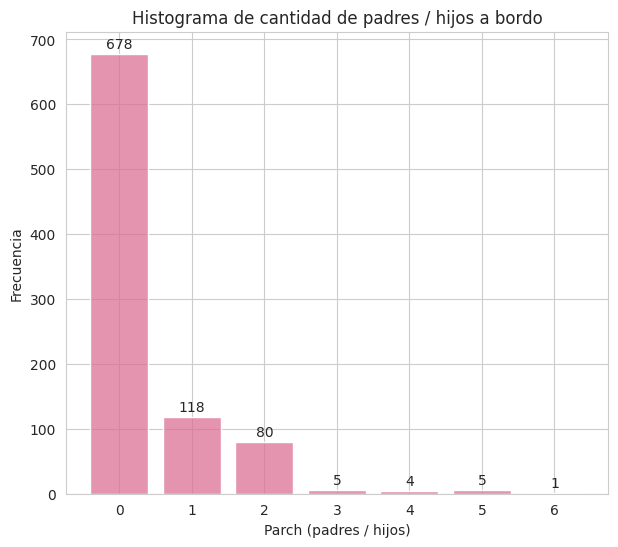


Porcentaje de cantidad de padres o hijos a bordo
--------------------------------------------------
Parch
0    76.094276
1    13.243547
2     8.978676
5     0.561167
3     0.561167
4     0.448934
6     0.112233
Name: proportion, dtype: float64
--------------------------------------------------


In [ ]:
sns.set_style("whitegrid")
# Histograma de cantidad de padres / hijos a bordo
plt.figure(figsize=(7, 6))
ax = sns.histplot(data=df, x='Parch', color='palevioletred',discrete=True, shrink=.8)
plt.title('Histograma de cantidad de padres / hijos a bordo')
plt.xlabel('Parch (padres / hijos)')
plt.ylabel('Frecuencia')
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.show()

print()
print("Porcentaje de cantidad de padres o hijos a bordo")
print("-"*50)
print(df['Parch'].value_counts(normalize=True) * 100)
print("-"*50)

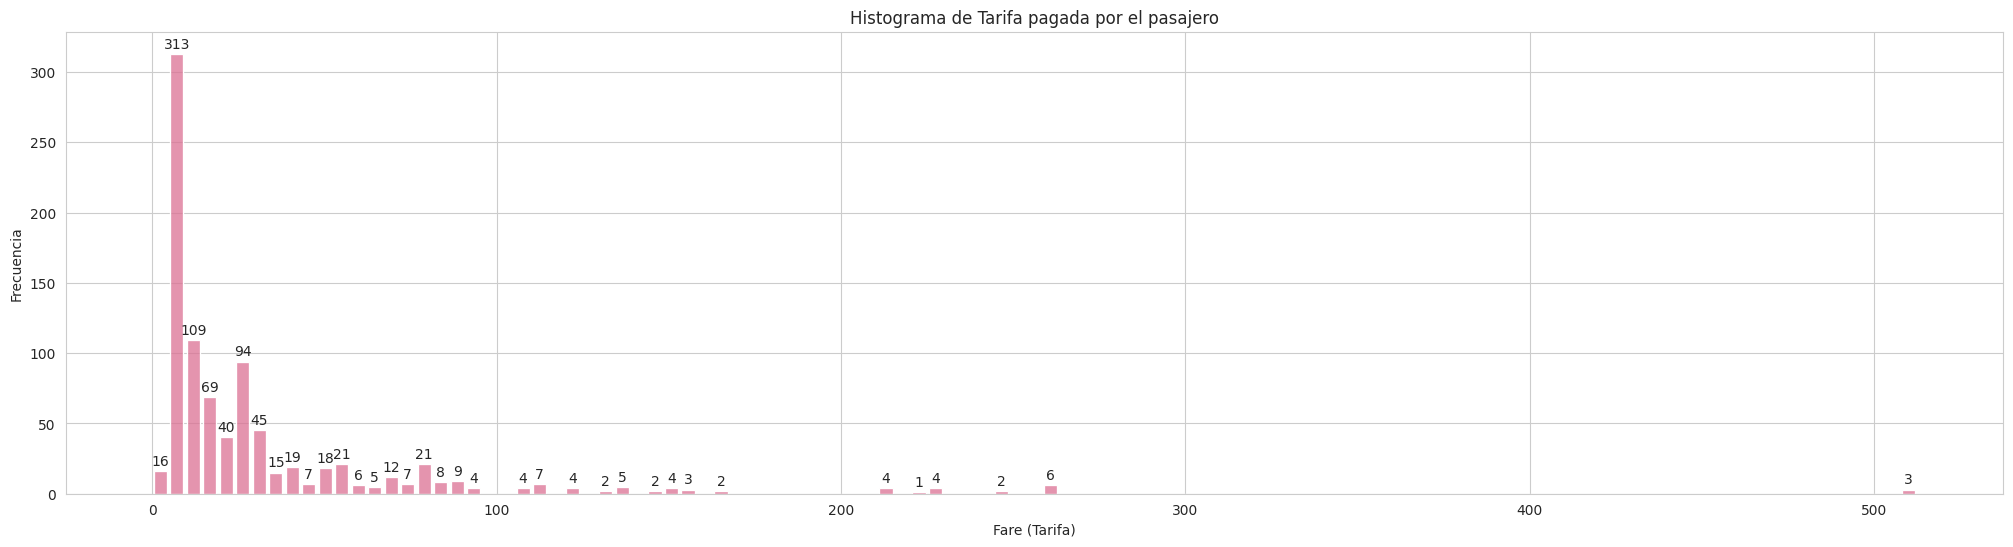

In [ ]:
sns.set_style("whitegrid")
# Histograma de Tarifa pagada por el pasajero
plt.figure(figsize=(25, 6))
ax = sns.histplot(data=df, x='Fare', color='palevioletred', shrink=.8)
plt.title('Histograma de Tarifa pagada por el pasajero')
plt.xlabel('Fare (Tarifa)')
plt.ylabel('Frecuencia')
for container in ax.containers:
    ax.bar_label(container, padding=2, fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
plt.show()

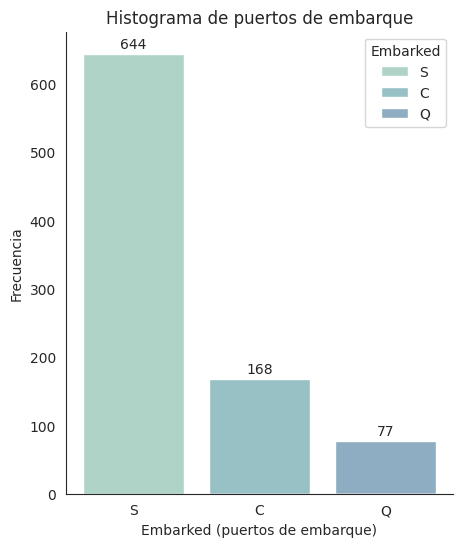


Porcentaje de puertos de embarque
--------------------------------------------------
Embarked
S    72.440945
C    18.897638
Q     8.661417
Name: proportion, dtype: float64
--------------------------------------------------


In [ ]:
sns.set_style("white")
# Histograma de puertos de embarque
plt.figure(figsize=(5, 6))
ax = sns.histplot(data=df, x='Embarked', hue='Embarked', palette='crest', discrete=True, shrink=.8)
plt.title('Histograma de puertos de embarque')
plt.xlabel('Embarked (puertos de embarque)')
plt.ylabel('Frecuencia')
for container in ax.containers:
    ax.bar_label(container, padding=2, fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
sns.despine()
plt.show()

print()
print("Porcentaje de puertos de embarque")
print("-"*50)
print(df['Embarked'].value_counts(normalize=True) * 100)
print("-"*50)

## Valores Duplicados

In [ ]:
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")
print()
print("Descartando filas con valores duplicados...")
df = df.drop_duplicates()
print()
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Número de filas: 891
Número de columnas: 12

Descartando filas con valores duplicados...

Número de filas: 891
Número de columnas: 12


## Valores Nulos

In [ ]:
print("Número de filas válidas por columna:")
print(df.count().to_string())

Número de filas válidas por columna:
PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889


In [ ]:
# Las edades faltantes la remplazaremos con la edad promedio de los pasajeros
df['Age'] = df['Age'].fillna(df['Age'].mean())
# Los valores faltantes tanto en Cabin como en embarqued seren remplasados con n/n para tener en consideracion los datos no conocidos
df['Cabin'] = df['Cabin'].fillna('n/n')
df['Embarked'] = df['Embarked'].fillna('n/n')

print("Número de filas válidas por columna:")
print(df.count().to_string())

Número de filas válidas por columna:
PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            891
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          891
Embarked       891


**Justificación del manejo de valores nulos:**

*   **Age:** Los valores faltantes en la columna 'Age' se reemplazaron con la edad promedio de los pasajeros. Esta es una estrategia común para la imputación de datos numéricos, ya que utiliza una medida central para llenar los vacíos sin introducir sesgos significativos si los datos faltantes son aleatorios.
*   **Cabin:** Los valores faltantes en la columna 'Cabin' se reemplazaron con 'n/n'. Dado el alto porcentaje de valores nulos en esta columna, imputar con un valor específico como 'n/n' permite mantener estos registros en el análisis sin intentar adivinar la cabina real, que sería poco fiable.
*   **Embarked:** Los valores faltantes en la columna 'Embarked' se reemplazaron con 'n/n'. Esta imputación permite mantener la consistencia en la columna y evitar errores en análisis posteriores que requieran valores no nulos.

## Valores Atipicos

Text(0.5, 0.98, 'Identificacion de Valores Atipicos')

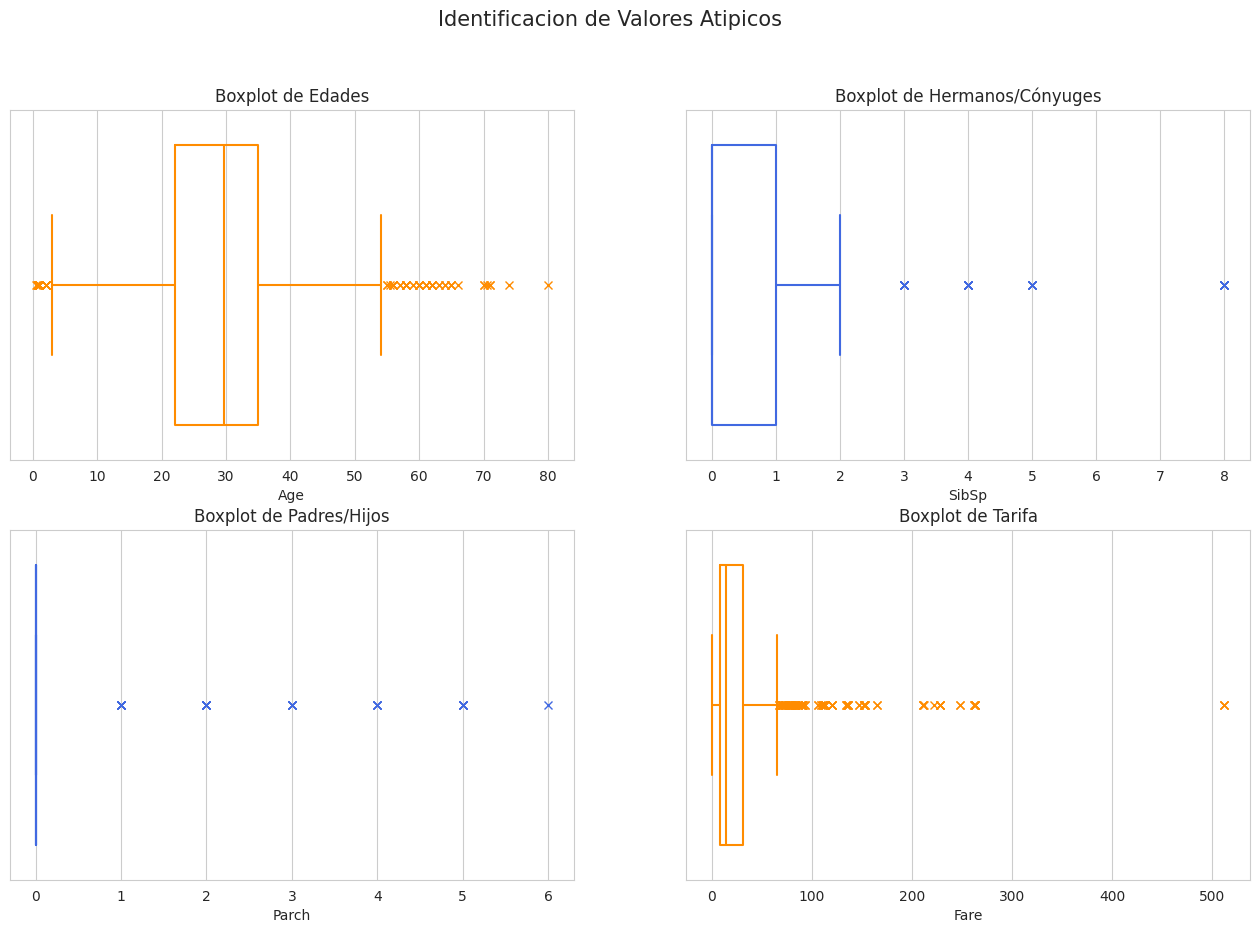

In [ ]:
sns.set_style("whitegrid")
fig, axs = plt.subplots(figsize=(16,10), ncols=2, nrows=2)
sns.boxplot(x=df['Age'], ax=axs[0][0], fill=False, color='darkorange',flierprops={"marker": "x"})
axs[0][0].set_title('Boxplot de Edades')
sns.boxplot(x=df['SibSp'], ax=axs[0][1], fill=False, color='royalblue',flierprops={"marker": "x"})
axs[0][1].set_title('Boxplot de Hermanos/Cónyuges')
sns.boxplot(x=df['Parch'], ax=axs[1][0], fill=False, color='royalblue',flierprops={"marker": "x"})
axs[1][0].set_title('Boxplot de Padres/Hijos')
sns.boxplot(x=df['Fare'], ax=axs[1][1], fill=False, color='darkorange',flierprops={"marker": "x"})
axs[1][1].set_title('Boxplot de Tarifa')
fig.suptitle('Identificacion de Valores Atipicos', fontsize=15)

Número de filas (con valores atípicos): 891
Eliminando valores atípicos...

Número de filas (sin valores atípicos): 721



Text(0.5, 0.98, 'Identificacion de Valores Atipicos')

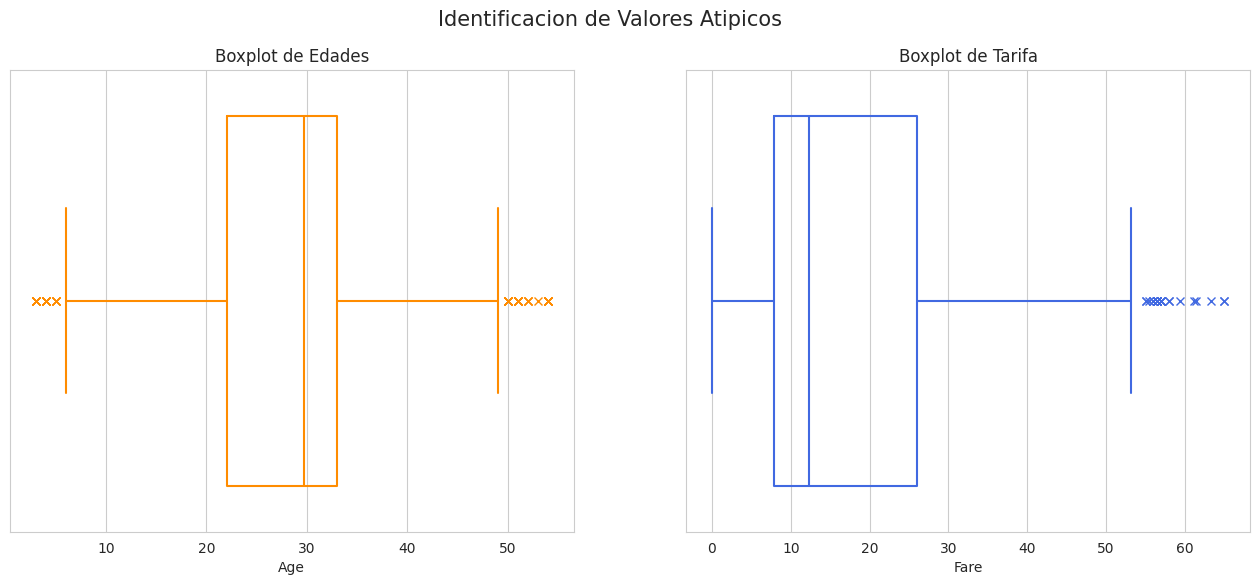

In [ ]:
columns_with_outliers = ['Age','Fare']
print(f"Número de filas (con valores atípicos): {df.shape[0]}")
print("Eliminando valores atípicos...")
Q1 = df[columns_with_outliers].quantile(0.25)
Q3 = df[columns_with_outliers].quantile(0.75)

IQR = Q3 - Q1

outlier_condition = ((df[columns_with_outliers] < (Q1 - 1.5 * IQR)) | (df[columns_with_outliers] > (Q3 + 1.5 * IQR))).any(axis=1)
df2 = df[~outlier_condition]
print()
print(f"Número de filas (sin valores atípicos): {df2.shape[0]}")
print()

sns.set_style("whitegrid")
fig, axs = plt.subplots(figsize=(16,6), ncols=2, nrows=1)
sns.boxplot(x=df2['Age'], ax=axs[0], fill=False, color='darkorange',flierprops={"marker": "x"})
axs[0].set_title('Boxplot de Edades')
sns.boxplot(x=df2['Fare'], ax=axs[1], fill=False, color='royalblue',flierprops={"marker": "x"})
axs[1].set_title('Boxplot de Tarifa')
fig.suptitle('Identificacion de Valores Atipicos', fontsize=15)

**Justificación de la eliminación de valores atípicos en 'Age' y 'Fare':**

Los valores atípicos en las columnas 'Age' y 'Fare' se eliminaron porque representan edades o tarifas que están significativamente fuera del rango de la mayoría de los pasajeros. Estos valores extremos, aunque reales, podrían distorsionar los análisis estadísticos y los modelos predictivos si se incluyeran sin tratamiento. Eliminar estos valores atípicos ayuda a enfocar el análisis en la distribución principal de la población de pasajeros y a obtener resultados más representativos.

**Justificación para mantener valores atípicos en 'SibSp' y 'Parch':**

Aunque las columnas 'SibSp' y 'Parch' también muestran valores atípicos (números altos de hermanos/cónyuges o padres/hijos a bordo), estos no se eliminaron por las siguientes razones:

* **Representan situaciones familiares reales:** Los valores atípicos en 'SibSp' y 'Parch' corresponden a familias numerosas que viajaban juntas. Eliminar estos registros significaría perder información valiosa sobre cómo el tamaño de la familia podría haber influido en la supervivencia.
* **Potencialmente relevantes para la supervivencia:** El número de familiares a bordo podría ser un factor importante en la probabilidad de supervivencia. Las personas que viajaban en grupos grandes podrían haber tenido diferentes dinámicas de evacuación o prioridades en comparación con los que viajaban solos. Mantener estos valores atípicos permite explorar esta posible relación.

En resumen, la decisión de eliminar o mantener valores atípicos depende de si representan errores de datos, eventos excepcionales que distorsionan el análisis general, o si son datos válidos que podrían ser relevantes para el fenómeno que se está estudiando. En este caso, los valores atípicos en 'Age' y 'Fare' se consideraron distorsiones potenciales para el análisis general, mientras que los de 'SibSp' y 'Parch' se consideraron información potencialmente relevante sobre la dinámica familiar a bordo.

## Evaluar Atributos Irrelevantes

In [ ]:
df2 = df2.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
print(df2.head())

   Survived  Pclass     Sex        Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.000000      1      0   7.2500        S
2         1       3  female  26.000000      0      0   7.9250        S
3         1       1  female  35.000000      1      0  53.1000        S
4         0       3    male  35.000000      0      0   8.0500        S
5         0       3    male  29.699118      0      0   8.4583        Q


**Justificación de la eliminación de atributos irrelevantes:**

*   **PassengerId:** Es un identificador único para cada pasajero y no tiene ninguna relación con la probabilidad de supervivencia.
*   **Name:** Aunque el nombre podría contener información sobre el título o el estado social, la complejidad de extraer y categorizar esta información lo hace menos útil en este análisis exploratorio inicial. Otros atributos como `Pclass` y `Fare` ya capturan aspectos relacionados con el estatus.
*   **Ticket:** El número de ticket es un identificador de transacción y no proporciona información relevante sobre los factores de supervivencia.
*   **Cabin:** Esta columna tiene un gran número de valores nulos (aproximadamente el 77%). Aunque podría indicar la ubicación en el barco, la cantidad significativa de datos faltantes limita su utilidad para el análisis general.

In [ ]:
pclass_mapping = {1: 'Primera Clase', 2: 'Segunda Clase', 3: 'Tercera Clase'}
df2['clase'] = df2['Pclass'].map(pclass_mapping)
display(df2.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,clase
0,0,3,male,22.000000,1,0,7.2500,S,Tercera Clase
2,1,3,female,26.000000,0,0,7.9250,S,Tercera Clase
3,1,1,female,35.000000,1,0,53.1000,S,Primera Clase
4,0,3,male,35.000000,0,0,8.0500,S,Tercera Clase
5,0,3,male,29.699118,0,0,8.4583,Q,Tercera Clase


## Analisis Estadistico

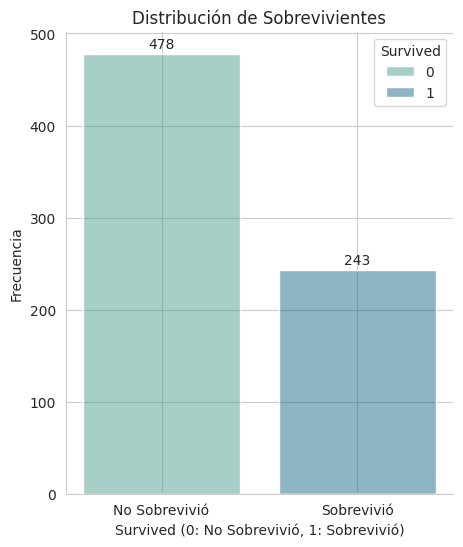


Moda de Survived: 0

Frecuencia y Porcentaje de Survived:
----------------------------------------
0 - No Sobrevivió, 1 - Sobrevivió
----------------------------------------
          Frecuencia  Porcentaje
Survived                        
0                478    66.29681
1                243    33.70319
----------------------------------------


In [ ]:
plt.figure(figsize=(5, 6))
ax = sns.histplot(data=df2, x='Survived', hue='Survived', palette='crest', discrete=True, shrink=.8)
plt.xticks([0, 1])
plt.title('Distribución de Sobrevivientes')
plt.xlabel('Survived (0: No Sobrevivió, 1: Sobrevivió)')
plt.ylabel('Frecuencia')
plt.xticks([0, 1], ['No Sobrevivió', 'Sobrevivió'])
for container in ax.containers:
    ax.bar_label(container, padding=2, fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
sns.despine()
plt.show()

print()

# Calcular la moda para 'Survived'
survived_mode = df2['Survived'].mode()[0]
print(f"Moda de Survived: {survived_mode}")

# Calcular la frecuencia de distribucion para 'Survived'
survived_counts = df2['Survived'].value_counts()
survived_percentages = df2['Survived'].value_counts(normalize=True) * 100

print("\nFrecuencia y Porcentaje de Survived:")
print("-" * 40)
print("0 - No Sobrevivió, 1 - Sobrevivió")
print("-" * 40)
print(pd.DataFrame({'Frecuencia': survived_counts, 'Porcentaje': survived_percentages}).to_string())
print("-" * 40)

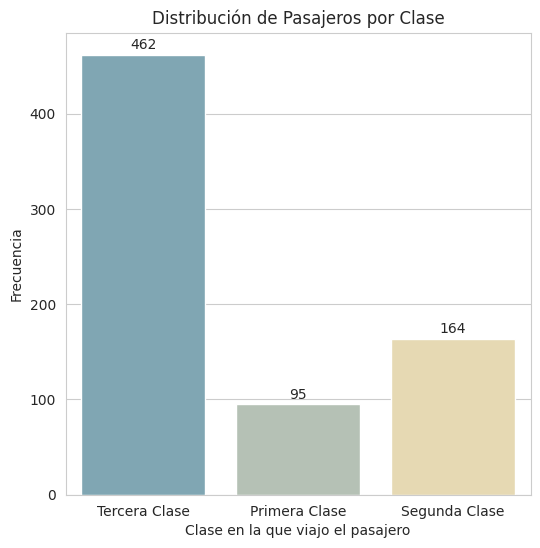


Moda de Pclass: 3
Mediana de Pclass: 3.0

Frecuencia y Porcentaje de Pclass:
----------------------------------------
1 - Primera Clase, 2 - Segunda Clase, 3 - Tercera Clase
----------------------------------------
        Frecuencia  Porcentaje
Pclass                        
3              462   64.077670
2              164   22.746186
1               95   13.176144
----------------------------------------


In [ ]:
plt.figure(figsize=(6, 6))
ax = sns.countplot(data=df2, x='clase', palette='blend:#7AB,#EDA',hue='clase')

for container in ax.containers:
    ax.bar_label(container, padding=2)

plt.title('Distribución de Pasajeros por Clase')
plt.xlabel('Clase en la que viajo el pasajero')
plt.ylabel('Frecuencia')
plt.show()

print()

# Calculo de la moda de 'Pclass'
pclass_mode = df2['Pclass'].mode()[0]
print(f"Moda de Pclass: {pclass_mode}")

# Calculo de la mediana de 'Pclass'
pclass_median = df2['Pclass'].median()
print(f"Mediana de Pclass: {pclass_median}")

# Calcular la distribución de frecuencia para 'Pclass'
pclass_counts = df2['Pclass'].value_counts()
pclass_percentages = df2['Pclass'].value_counts(normalize=True) * 100

print("\nFrecuencia y Porcentaje de Pclass:")
print("-" * 40)
print("1 - Primera Clase, 2 - Segunda Clase, 3 - Tercera Clase")
print("-" * 40)
print(pd.DataFrame({'Frecuencia': pclass_counts, 'Porcentaje': pclass_percentages}).to_string())
print("-" * 40)

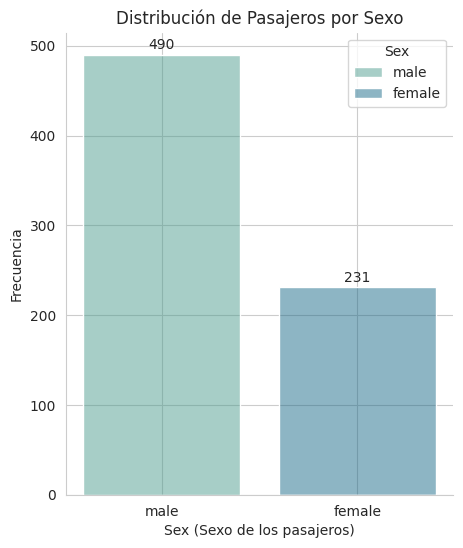


Moda de Sex: male

Frecuencia y Porcentaje de Sex:
-------------------------------------
male - Hombres, female - Mujeres
-------------------------------------
        Frecuencia  Porcentaje
Sex                           
male           490   67.961165
female         231   32.038835
-------------------------------------


In [ ]:
# Histograma Sexo de los pasajeros
plt.figure(figsize=(5, 6))
ax = sns.histplot(data=df2, x='Sex', hue='Sex', palette='crest', shrink=.8)
plt.title('Distribución de Pasajeros por Sexo')
plt.xlabel('Sex (Sexo de los pasajeros)')
plt.ylabel('Frecuencia')
for container in ax.containers:
    ax.bar_label(container, padding=2, fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
sns.despine()
plt.show()

print()

# Calcular moda de 'Sex'
sex_mode = df2['Sex'].mode()[0]
print(f"Moda de Sex: {sex_mode}")

# Calcular la frecuencia de distribucion para 'Sex'
sex_counts = df2['Sex'].value_counts()
sex_percentages = df2['Sex'].value_counts(normalize=True) * 100

print("\nFrecuencia y Porcentaje de Sex:")
print("-" * 37)
print("male - Hombres, female - Mujeres")
print("-" * 37)
print(pd.DataFrame({'Frecuencia': sex_counts, 'Porcentaje': sex_percentages}).to_string())
print("-" * 37)


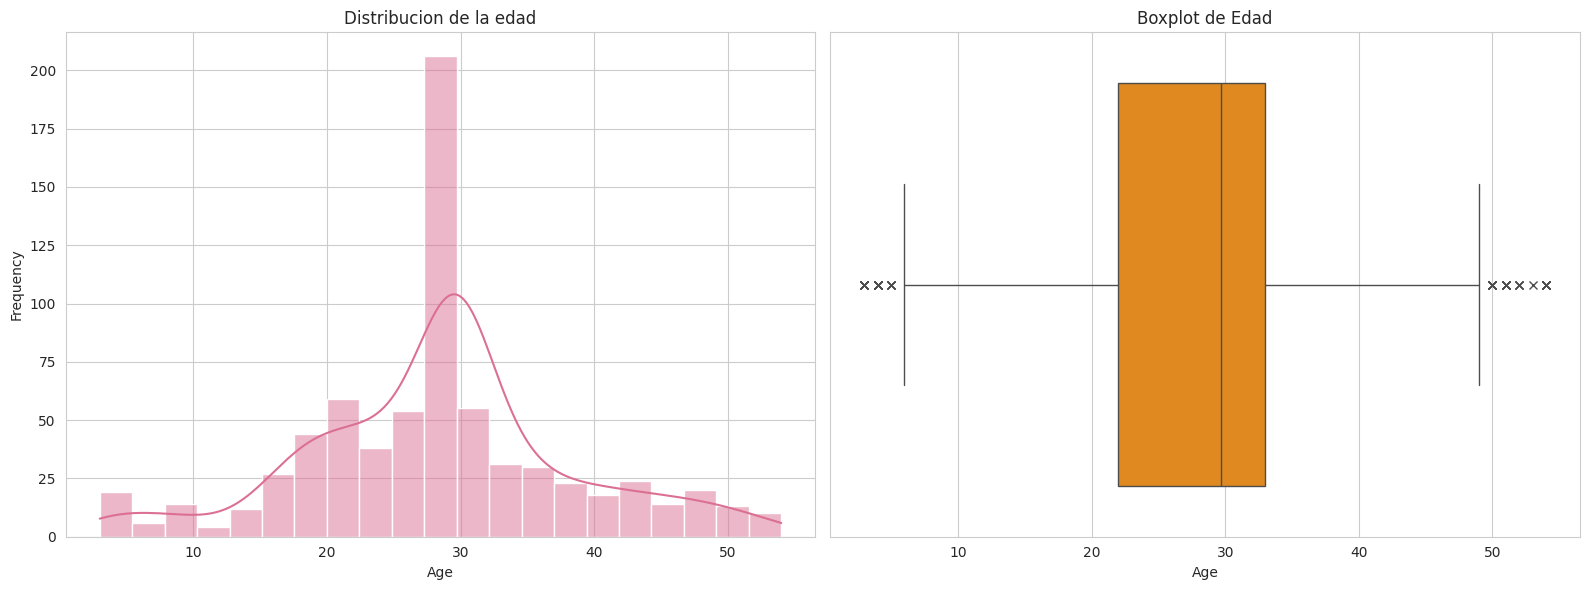


Promedio de Age: 28.48
Mediana de Age: 29.70
Moda de Age: 29.70

Resumen estadistico de Age:
count    721.000000
mean      28.476085
std       10.043466
min        3.000000
25%       22.000000
50%       29.699118
75%       33.000000
max       54.000000
Name: Age, dtype: float64


In [ ]:
fig, axs = plt.subplots(figsize=(16, 6), ncols=2, nrows=1)
sns.histplot(data=df2, x='Age', color='palevioletred', kde=True, ax=axs[0])
axs[0].set_title('Distribucion de la edad')
axs[0].set_xlabel('Age')
axs[0].set_ylabel('Frequency')

sns.boxplot(data=df2, x='Age', color='darkorange', flierprops={"marker": "x"}, ax=axs[1])
axs[1].set_title('Boxplot de Edad')
axs[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

print()

# Calcular la media, mediana y moda para 'Age'
age_mean = df2['Age'].mean()
age_median = df2['Age'].median()
age_mode = df2['Age'].mode()[0]

print(f"Promedio de Age: {age_mean:.2f}")
print(f"Mediana de Age: {age_median:.2f}")
print(f"Moda de Age: {age_mode:.2f}")

# Usar describe() para un resumen de 'Age'
print("\nResumen estadistico de Age:")
print(df2['Age'].describe())

**Interpretación de la distribución de la edad:** La columna 'Age' representa la edad de los pasajeros del Titanic. La edad promedio es de aproximadamente 28.48 años. La mediana (29.70) y la moda (29.70) son muy cercanas al promedio, lo que sugiere una distribución de edad relativamente simétrica. El histograma muestra que la distribución de edad está ligeramente sesgada a la derecha, con la mayoría de los pasajeros entre los 20 y 40 años. El resumen estadístico describe() confirma que la mitad de los pasajeros tienen 29.70 años o menos, y el 75% tienen 33 años o menos. El diagrama de caja visualiza esta distribución, mostrando que la mayoría de los datos se encuentran entre aproximadamente 22 y 33 años, con algunos valores atípicos que representan pasajeros más jóvenes (hasta 3 años) y mayores (hasta 54 años).

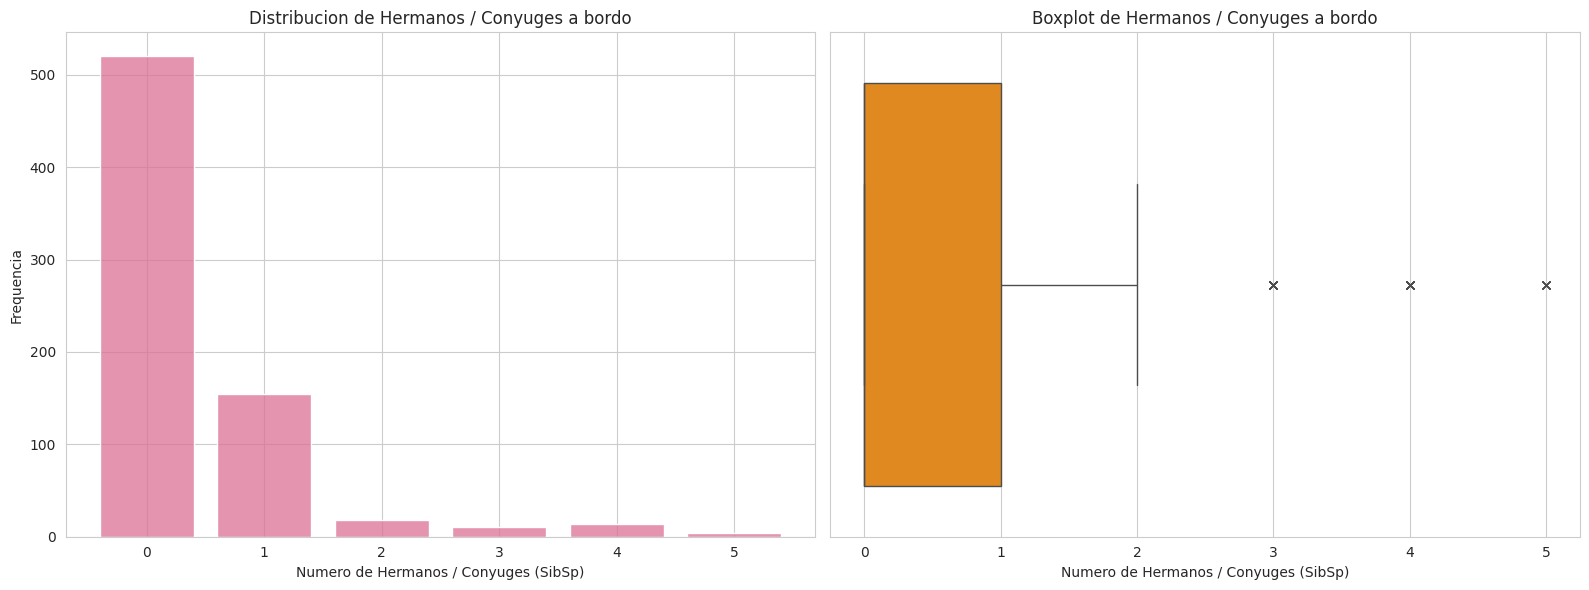


Promedio de SibSp: 0.41
Mediana de SibSp: 0.00
Moda de SibSp: 0.00

Resumen Estadistico de SibSp:
count    721.000000
mean       0.414702
std        0.853916
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        5.000000
Name: SibSp, dtype: float64


In [ ]:
fig, axs = plt.subplots(figsize=(16, 6), ncols=2, nrows=1)

sns.histplot(data=df2, x='SibSp', color='palevioletred', discrete=True, shrink=.8, ax=axs[0])
axs[0].set_title('Distribucion de Hermanos / Conyuges a bordo')
axs[0].set_xlabel('Numero de Hermanos / Conyuges (SibSp)')
axs[0].set_ylabel('Frequencia')
axs[0].set_xticks(range(int(df2['SibSp'].min()), int(df2['SibSp'].max()) + 1))


sns.boxplot(data=df2, x='SibSp', color='darkorange', flierprops={"marker": "x"}, ax=axs[1])
axs[1].set_title('Boxplot de Hermanos / Conyuges a bordo')
axs[1].set_xlabel('Numero de Hermanos / Conyuges (SibSp)')

plt.tight_layout()
plt.show()

print()

# Calcular la media, mediana y moda para 'SibSp'
sibsp_mean = df2['SibSp'].mean()
sibsp_median = df2['SibSp'].median()
sibsp_mode = df2['SibSp'].mode()[0]

print(f"Promedio de SibSp: {sibsp_mean:.2f}")
print(f"Mediana de SibSp: {sibsp_median:.2f}")
print(f"Moda de SibSp: {sibsp_mode:.2f}")

# Usar describe() para un resumen de 'SibSp'
print("\nResumen Estadistico de SibSp:")
print(df2['SibSp'].describe())

**Interpretación de la distribución de SibSp:** La columna 'SibSp' representa el número de hermanos o cónyuges que un pasajero tenía a bordo del Titanic. La media es de 0.41, lo que indica que en promedio los pasajeros tenían menos de un hermano o cónyuge a bordo. Tanto la mediana como la moda son 0, lo que sugiere que la mayoría de los pasajeros viajaban solos sin hermanos ni cónyuges. El resumen estadístico de describe() confirma esto, mostrando que el 75% de los pasajeros tenían 1 o menos hermanos/cónyuges a bordo. El histograma visualiza esta distribución altamente sesgada hacia 0, con una rápida disminución en la frecuencia a medida que aumenta el número de hermanos/cónyuges. El diagrama de caja también refuerza esto, mostrando la mediana en 0 y resaltando los valores atípicos que representan a los pasajeros con más de 1 hermano o cónyuge a bordo (hasta 5). Esta distribución sugiere que muchos pasajeros viajaban solos o en parejas, lo que podría ser un factor a considerar al analizar las tasas de supervivencia, ya que las personas que viajaban con familiares podrían haber tenido diferentes comportamientos o prioridades durante el desastre.

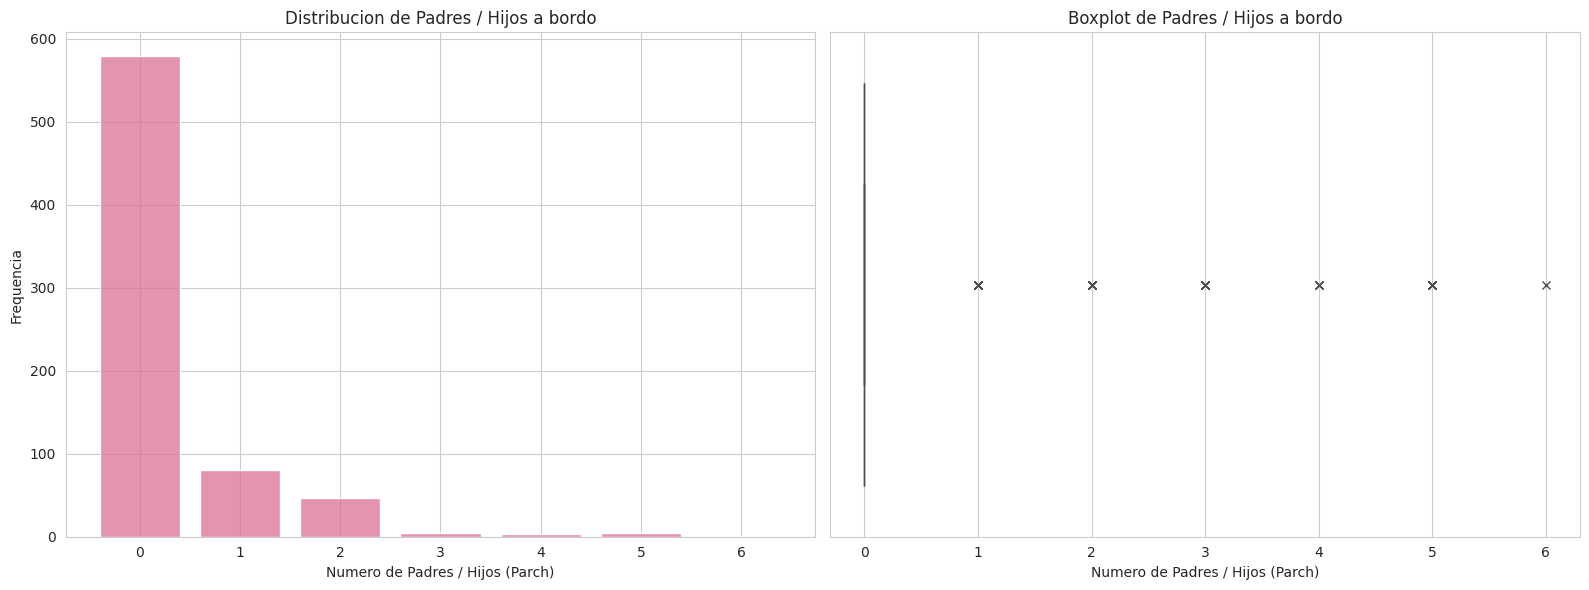


Promedio de Parch: 0.32
Mediana de Parch: 0.00
Moda de Parch: 0.00

Resumen estadistico de Parch:
count    721.000000
mean       0.323162
std        0.788549
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000


In [ ]:
fig, axs = plt.subplots(figsize=(16, 6), ncols=2, nrows=1)

sns.histplot(data=df2, x='Parch', color='palevioletred', discrete=True, shrink=.8, ax=axs[0])
axs[0].set_title('Distribucion de Padres / Hijos a bordo')
axs[0].set_xlabel('Numero de Padres / Hijos (Parch)')
axs[0].set_ylabel('Frequencia')
axs[0].set_xticks(range(int(df2['Parch'].min()), int(df2['Parch'].max()) + 1))

sns.boxplot(data=df2, x='Parch', color='darkorange', flierprops={"marker": "x"}, ax=axs[1])
axs[1].set_title('Boxplot de Padres / Hijos a bordo')
axs[1].set_xlabel('Numero de Padres / Hijos (Parch)')

plt.tight_layout()
plt.show()

print()

# Calcular la media, mediana y moda para 'Parch'
parch_mean = df2['Parch'].mean()
parch_median = df2['Parch'].median()
parch_mode = df2['Parch'].mode()[0]

print(f"Promedio de Parch: {parch_mean:.2f}")
print(f"Mediana de Parch: {parch_median:.2f}")
print(f"Moda de Parch: {parch_mode:.2f}")

# Usar describe() para un resumen de 'Parch'
print("\nResumen estadistico de Parch:")
print(df2['Parch'].describe().to_string())

Interpretación de la distribución de la PARCH: La columna 'Parch' representa el número de padres o hijos que un pasajero tenía a bordo del Titanic. La media (0.32), la mediana (0.00) y la moda (0.00) indican que el escenario más común era un pasajero que viajaba sin padres ni hijos. El resumen estadístico de describe() confirma esto, mostrando que el 75% de los pasajeros tenían 0 padres/hijos a bordo. El histograma refuerza visualmente esto, con una frecuencia muy alta a 0 y una rápida disminución de las frecuencias para un número creciente de padres/hijos. El diagrama de caja también muestra la mediana en 0 y resalta los valores atípicos que representan a los pasajeros con unos pocos padres o hijos a bordo (hasta 6). Esta distribución sugiere que muchos pasajeros viajaron solos o en grupos más pequeños, lo que podría ser relevante para las tasas de supervivencia, ya que las personas que viajan con la familia podrían haber tenido diferentes prioridades o desafíos durante la evacuación.

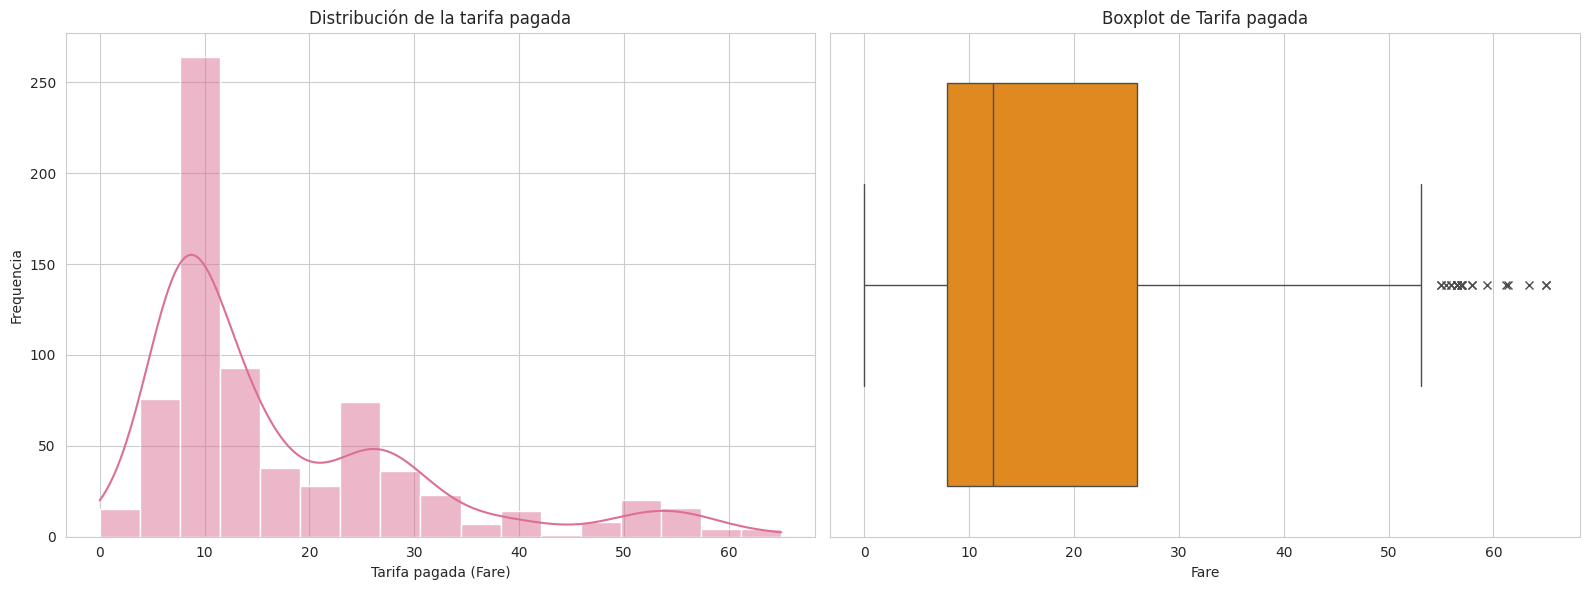

Promedio de Fare: 17.39
Mediana de Fare: 12.28
Moda de Fare: 8.05

Resumen Estadistico de Fare:
count    721.000000
mean      17.389845
std       13.563036
min        0.000000
25%        7.895800
50%       12.275000
75%       26.000000
max       65.000000


In [ ]:
fig, axs = plt.subplots(figsize=(16, 6), ncols=2, nrows=1)

sns.histplot(data=df2, x='Fare', color='palevioletred', kde=True, ax=axs[0])
axs[0].set_title('Distribución de la tarifa pagada')
axs[0].set_xlabel('Tarifa pagada (Fare)')
axs[0].set_ylabel('Frequencia')

sns.boxplot(data=df2, x='Fare', color='darkorange', flierprops={"marker": "x"}, ax=axs[1])
axs[1].set_title('Boxplot de Tarifa pagada')
axs[1].set_xlabel('Fare')

plt.tight_layout()
plt.show()

# Calcular la media, mediana y moda para 'Fare'
fare_mean = df2['Fare'].mean()
fare_median = df2['Fare'].median()
fare_mode = df2['Fare'].mode()[0]

print(f"Promedio de Fare: {fare_mean:.2f}")
print(f"Mediana de Fare: {fare_median:.2f}")
print(f"Moda de Fare: {fare_mode:.2f}")

# Use describe() for a summary of 'Fare'
print("\nResumen Estadistico de Fare:")
print(df2['Fare'].describe().to_string())

Interpretación de la distribución de tarifas: la columna 'Fare' representa la cantidad de dinero pagado por cada pasajero por su boleto. La tarifa promedio es 17.39, la mediana es 12.28 y la moda es 8.05. El resumen estadístico y las visualizaciones muestran que la distribución de las tarifas está muy sesgada hacia la derecha, y la mayoría de los pasajeros pagan una tarifa más baja. El diagrama de caja indica la presencia de varios valores atípicos a valores de tarifas más altos, incluso después del proceso de eliminación de valores atípicos iniciales. Se espera que la tarifa pagada esté fuertemente relacionada con la clase de pasajeros (PCLASS), con tarifas más altas correspondientes a las clases más altas (1 y segundo). Las tarifas más altas y las clases de pasajeros más altas generalmente se asocian con una mayor probabilidad de supervivencia.

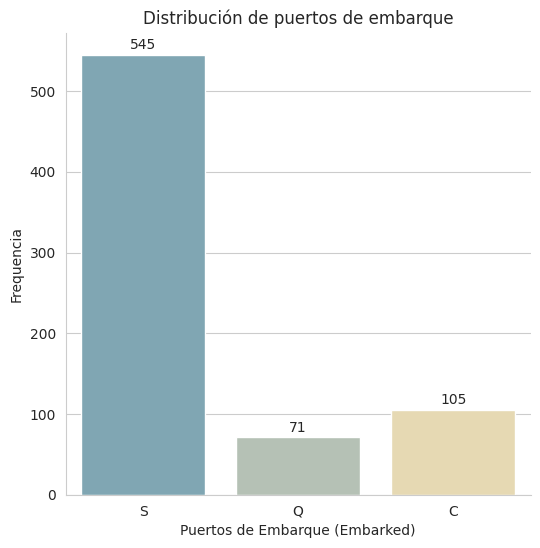


Moda de Embarked: S

Frecuencia y Porcentaje de Embarked:
-------------------------------------
S - Southampton, C - Cherbourg, Q - Queenstown
-------------------------------------
          Frecuencia  Porcentaje
Embarked                        
S                545   75.589459
C                105   14.563107
Q                 71    9.847434
-------------------------------------


In [ ]:
plt.figure(figsize=(6, 6))
ax = sns.countplot(data=df2, x='Embarked', palette='blend:#7AB,#EDA',hue='Embarked')

for container in ax.containers:
    ax.bar_label(container, padding=2)

plt.title('Distribución de puertos de embarque')
plt.xlabel('Puertos de Embarque (Embarked)')
plt.ylabel('Frequencia')
sns.despine()
plt.show()

print()

# Calcular moda para 'Embarked'
embarked_mode = df2['Embarked'].mode()[0]
print(f"Moda de Embarked: {embarked_mode}")

# Calcular frecuencia de distribucion para 'Embarked'
embarked_counts = df2['Embarked'].value_counts()
embarked_percentages = df2['Embarked'].value_counts(normalize=True) * 100

print("\nFrecuencia y Porcentaje de Embarked:")
print("-" * 37)
print("S - Southampton, C - Cherbourg, Q - Queenstown")
print("-" * 37)
print(pd.DataFrame({'Frecuencia': embarked_counts, 'Porcentaje': embarked_percentages}).to_string())
print("-" * 37)

Interpretación de la distribución de Embarked: la columna 'Embarked' indica el puerto donde cada pasajero abordó el Titanic. La moda es 's', lo que significa que el puerto más común de embarque fue Southampton (s). La frecuencia y la distribución porcentual muestran que la mayoría de los pasajeros se embarcaron de Southampton (S), seguido de Cherbourg (C) y luego Queenstown (Q). Se imputó un pequeño número de valores como 'n/n' para puertos desconocidos. Esta distribución es confirmada visualmente por el Histo, con la barra para que 's' sea significativamente más alta que los demás. El puerto de embarque podría ser relevante para la supervivencia, ya que diferentes puertos podrían haber tenido pasajeros de diferentes antecedentes socioeconómicos o con diferentes distribuciones de PCLASS, que a su vez podrían influir en las tasas de supervivencia.

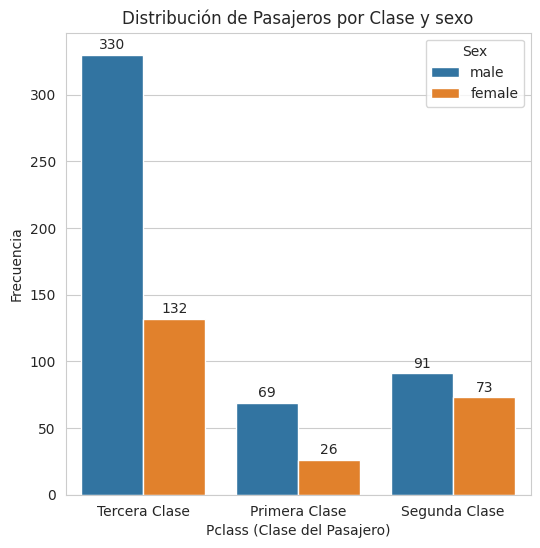

In [ ]:
plt.figure(figsize=(6, 6))
ax = sns.countplot(data=df2, x='clase',hue='Sex')

for container in ax.containers:
    ax.bar_label(container, padding=2)

plt.title('Distribución de Pasajeros por Clase y sexo')
plt.xlabel('Pclass (Clase del Pasajero)')
plt.ylabel('Frecuencia')
plt.show()

En este grafico podemos ver como se distribuyeron los pasajeros segun genero en cada clase apreciamos que en tercera clase se encuentran tanto la mayor cantidad de hombres como mujeres pero la cantidad de hombres casi triplica a la de mujeres y de forma similar sobrepasa por + del triple a los hombres de primera y segunda clase, en cambio las cantidad de mujeres en general no tiene tanta diferencia a ecepcion de las mujeres que viajaban en primera clase

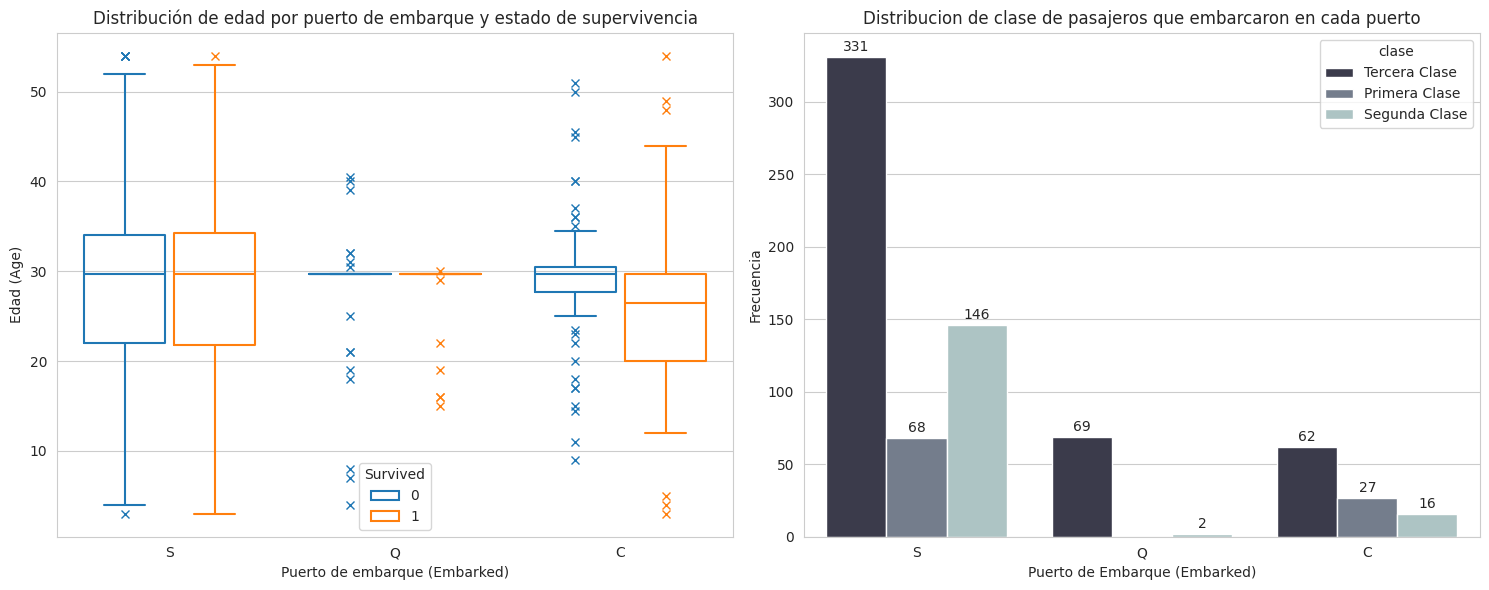

In [ ]:
fig, axs = plt.subplots(figsize=(15, 6), ncols=2, nrows=1)

sns.boxplot(data=df2, x="Embarked", y="Age", hue="Survived", flierprops={"marker": "x"}, fill=False, gap=.1, ax=axs[0])
axs[0].set_title('Distribución de edad por puerto de embarque y estado de supervivencia')
axs[0].set_xlabel('Puerto de embarque (Embarked)')
axs[0].set_ylabel('Edad (Age)')

ax2 = sns.countplot(data=df2, x='Embarked', hue='clase', palette='bone', ax=axs[1])
ax2.set_title('Distribucion de clase de pasajeros que embarcaron en cada puerto')
ax2.set_xlabel('Puerto de Embarque (Embarked)')
ax2.set_ylabel('Frecuencia')
for container in ax2.containers:
    ax2.bar_label(container, padding=2)

plt.tight_layout()
plt.show()

Podemos ver en el boxplot que en el puerto de embarque S las distribuciones de edades de pasajeros tanto que sobrevivieron 1 como que no sobrivibieron 0 son similares con un pequeño mayor rango de edades entre los sobreviviente, en el puerto Q en cambio todo el rango interquartil se agrupa en los ~30 años presentando tanto en los no sobrevivientes como sobrevibientes solo outliers en otras edades, los outliers de los no sobrevibientes son mas y se distribuyen desde los 40 a menos de 10 años, en el puerto de embarque C por otro lado podemos apreciar una tendencia clara teniendo los no sobrevivientes un rango intercuartil entre los ~27 y 32 años en cambio los no sobrevientes en general teniendo 30 años o menos, ambos grupos presentan outliers de niños menores a 10 años y personas mayores a 40

El puerto de embarque S es el puerto en el que mas pasajeros se embarcaron de todas las clases, 331 pasajeros de tercera clase, 146 de segunda clase y 68 de primera clase, en el puerto Q se embarcaron 69 pasajeros de tercera clase y 2 pasajeros de segunda, en este puerto no se embarco ningun pasajero de primera clase, y en el puerto C se embarcaron 62 pasajeros de tercera clase, 27 pasajeros de primera y 16 de segunda.

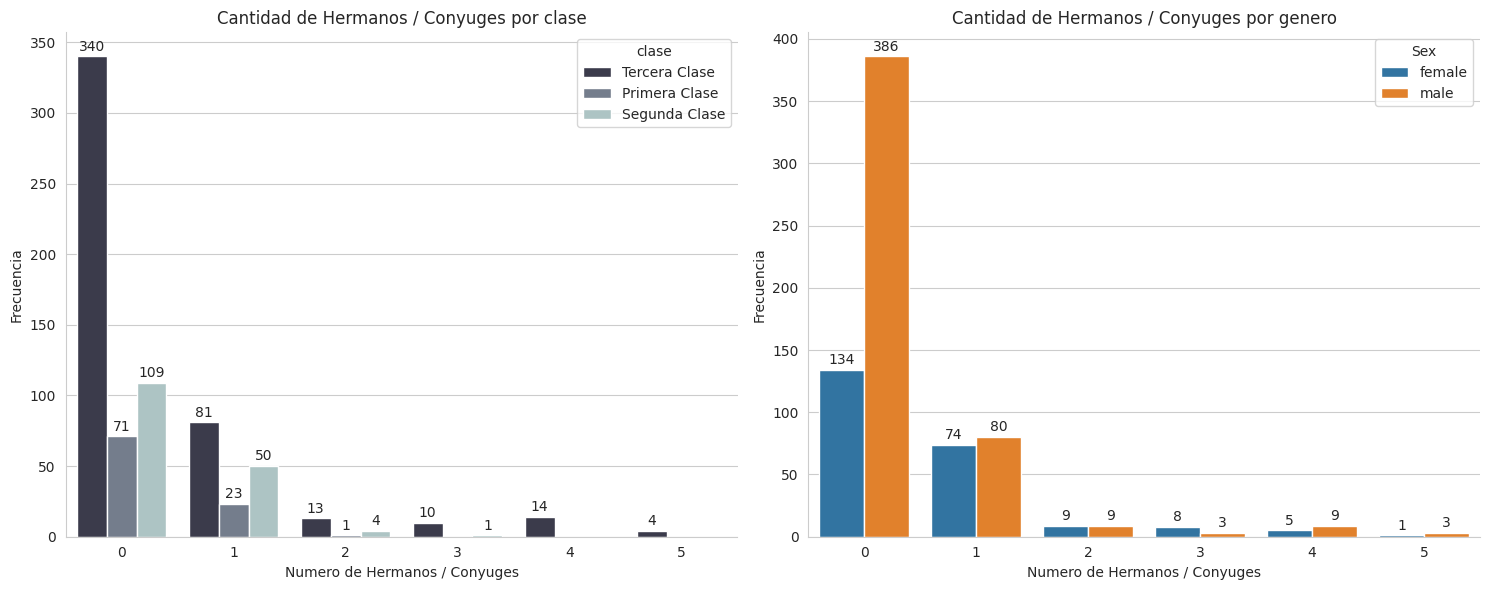

In [ ]:
fig, axs = plt.subplots(figsize=(15, 6), ncols=2, nrows=1)

ax1 = sns.countplot(data=df2, x='SibSp', hue='clase', palette='bone', ax=axs[0])
ax1.set_title('Cantidad de Hermanos / Conyuges por clase')
ax1.set_xlabel('Numero de Hermanos / Conyuges')
ax1.set_ylabel('Frecuencia')
for container in ax1.containers:
    ax1.bar_label(container, padding=2)

ax2 = sns.countplot(data=df2, x='SibSp', hue='Sex', ax=axs[1])
ax2.set_title('Cantidad de Hermanos / Conyuges por genero')
ax2.set_xlabel('Numero de Hermanos / Conyuges')
ax2.set_ylabel('Frecuencia')
for container in ax2.containers:
    ax2.bar_label(container, padding=2)

plt.tight_layout()
sns.despine()
plt.show()

En el primer grafico podemos apreciar la distribucion de la cantidad de hermanos o conyuges segun la clase del pasajero, podemos apreciar que en general la mayoria de personas pertenecientes a cada clase traian a bordo a 0 hermanos o conyuges, para pasajeros de tercera clase las cantidades de hermanos o conyuges mas comunes son: 1 (81 pasajeros), 4 (14 pasajeros) y 2 (13 pasajeros)

Para pasajeros de segunda clase: 1 (50 pasajeros), 2 (4 pasajeros) y 3 (1 pasajero)

Para pasajeros de primera clase: 1 (23 pasajeros) y 2 (1 pasajero)

En el segundo grafico se puede ver la distribucion de cantidad de hermanos o conyuges a bordo por sexo del pasajero, podemos ver nuevamente que la cantidad mas comun para ambos generos es 0 hermanos o conyuges a bordo pero en las siguientes cantidadesde hermanos o conyuges a bordo podemos observar que no existe tanta diferencia para hombres y mujeres.

pasajeros con 1 conyuge o hermano a bordo: 74 mujeres y 80 hombres

pasajeros con 2 conyuges o hermanos a bordo: 9 hombres y mujeres

pasajeros con 3 conyuges o hermanos a bordo: 8 mujeres y 3 hombres

pasajeros con 4 conyuges o hermanos a bordo: 5 mujeres y 9 hombres

pasajeros con 5 conyuges o hermanos a bordo: 1 mujer y 3 hombres

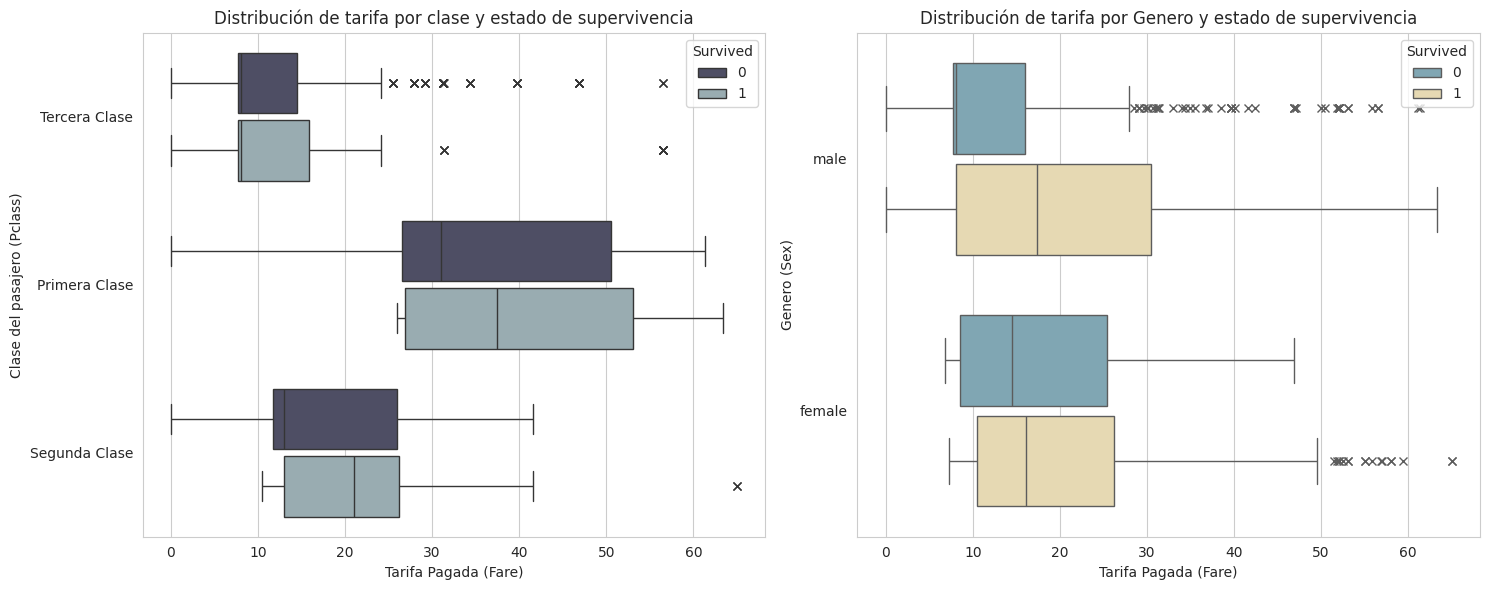

In [ ]:
fig, axs = plt.subplots(figsize=(15, 6), ncols=2, nrows=1)

sns.boxplot(data=df2, x="Fare", y="clase", hue="Survived", flierprops={"marker": "x"}, palette='bone', gap=.1, ax=axs[0])
axs[0].set_title('Distribución de tarifa por clase y estado de supervivencia')
axs[0].set_ylabel('Clase del pasajero (Pclass)')
axs[0].set_xlabel('Tarifa Pagada (Fare)')

ax2 = sns.boxplot(data=df2, x="Fare", y="Sex", hue="Survived", flierprops={"marker": "x"}, palette='blend:#7AB,#EDA', gap=.1, ax=axs[1])
ax2.set_title('Distribución de tarifa por Genero y estado de supervivencia')
ax2.set_ylabel('Genero (Sex)')
ax2.set_xlabel('Tarifa Pagada (Fare)')

plt.tight_layout()
plt.show()

En el primer grafico podemos ver la tarifa pagada por clase y estado de supervivencia, en general se logra apreciar una relacion directa entre la tarifa pagada y la clase del pasajero logrando distingir 3 grupos claros en distintos rangos de tarifas, a su ves podemos notar que entre los sobrevibientes se solia pagar ligeramente una tarifa mas alta a los no sobrevientes en cada clase, teniendo tanto en primera como en segunda clase un promedio mayor de tarifa.

En el segundo grafico podemos ver la tarifa pagada segun Genero y estado de supervivencia, en este grafico podemos notar que dentro de los hombre los que sobrevibieron pagaron en promedio una tarifa mucho mas alta que los que no lo hicieron, incluso superando el Q3 de la tarifa pagada por los no sobrevibientes y el Q3 de los sobrevibientes llegando hasta 30, en cambio las mujeres en general tanto sobrevibientes como no sobrevibientes pagaron tarifas similares habiendo pagado solo ligeramente mas las sobrevibientes.

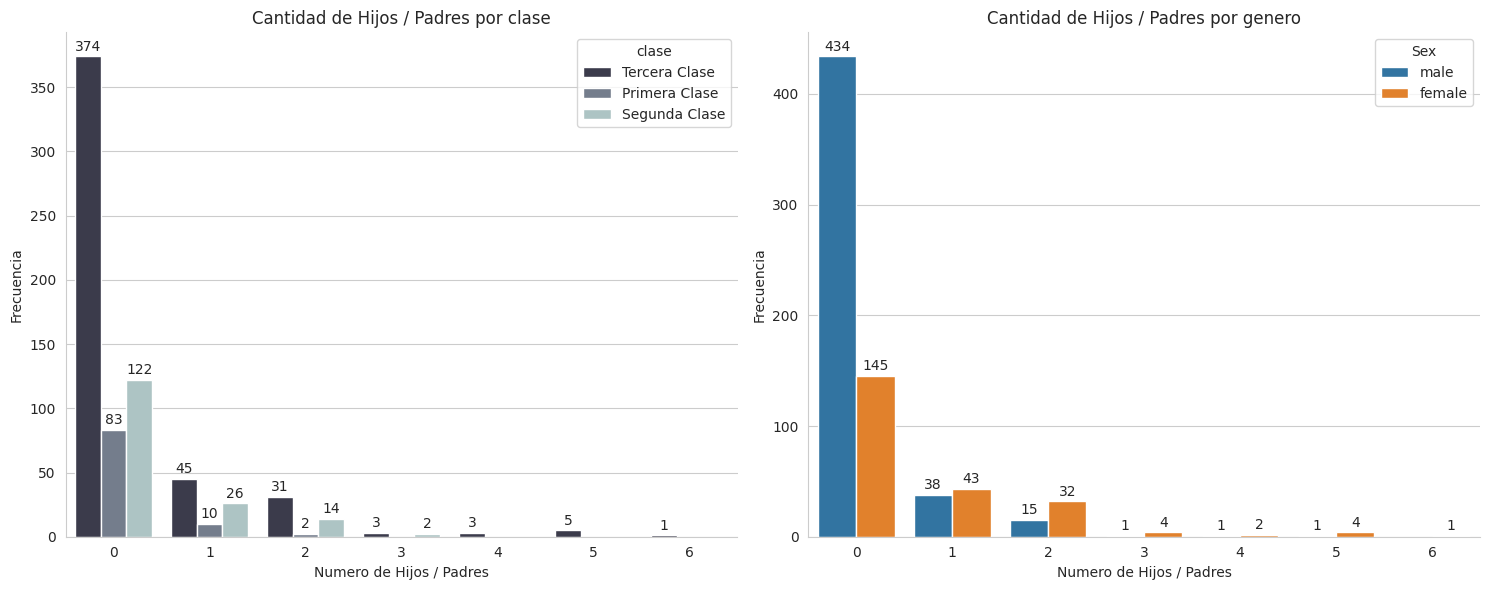

In [ ]:
fig, axs = plt.subplots(figsize=(15, 6), ncols=2, nrows=1)

ax1 = sns.countplot(data=df2, x='Parch', hue='clase', palette='bone', ax=axs[0])
ax1.set_title('Cantidad de Hijos / Padres por clase')
ax1.set_xlabel('Numero de Hijos / Padres')
ax1.set_ylabel('Frecuencia')
for container in ax1.containers:
    ax1.bar_label(container, padding=2)

ax2 = sns.countplot(data=df2, x='Parch', hue='Sex', ax=axs[1])
ax2.set_title('Cantidad de Hijos / Padres por genero')
ax2.set_xlabel('Numero de Hijos / Padres')
ax2.set_ylabel('Frecuencia')
for container in ax2.containers:
    ax2.bar_label(container, padding=2)

plt.tight_layout()
sns.despine()
plt.show()

En el primer grafico podemos apreciar la distribucion de la cantidad de Hijos o Padres segun la clase del pasajero, podemos apreciar que en general la mayoria de personas pertenecientes a cada clase traian a bordo a 0 Hijos o Padres, para pasajeros de tercera clase las cantidades de Hijos o Padres mas comunes son: 1 (45 pasajeros), 2 (31 pasajeros) y 5 (5 pasajeros)

Para pasajeros de segunda clase: 1 (26 pasajeros), 2 (14 pasajeros) y 3 (2 pasajero)

Para pasajeros de primera clase: 1 (10 pasajeros) y 2 (2 pasajero)

En el segundo grafico se puede ver la distribucion de cantidad de Hijos o Padres a bordo por sexo del pasajero, podemos ver nuevamente que la cantidad mas comun para ambos generos es 0 Hijos o Padres a bordo pero en las siguientes cantidades de hermanos o conyuges a bordo podemos observar que no existe tanta diferencia para hombres y mujeres.

pasajeros con 1 Hijo o Padre a bordo: 38 mujeres y 43 hombres

pasajeros con 2 Hijos o Padres a bordo: 15 hombres y 32 mujeres

pasajeros con 3 Hijos o Padres a bordo: 1 mujeres y 4 hombres

pasajeros con 4 Hijos o Padres a bordo: 1 mujeres y 2 hombres

pasajeros con 5 Hijos o Padres a bordo: 1 mujer y 4 hombres

pasajeros con 6 Hijos o Padres a bordo: 1 hombre


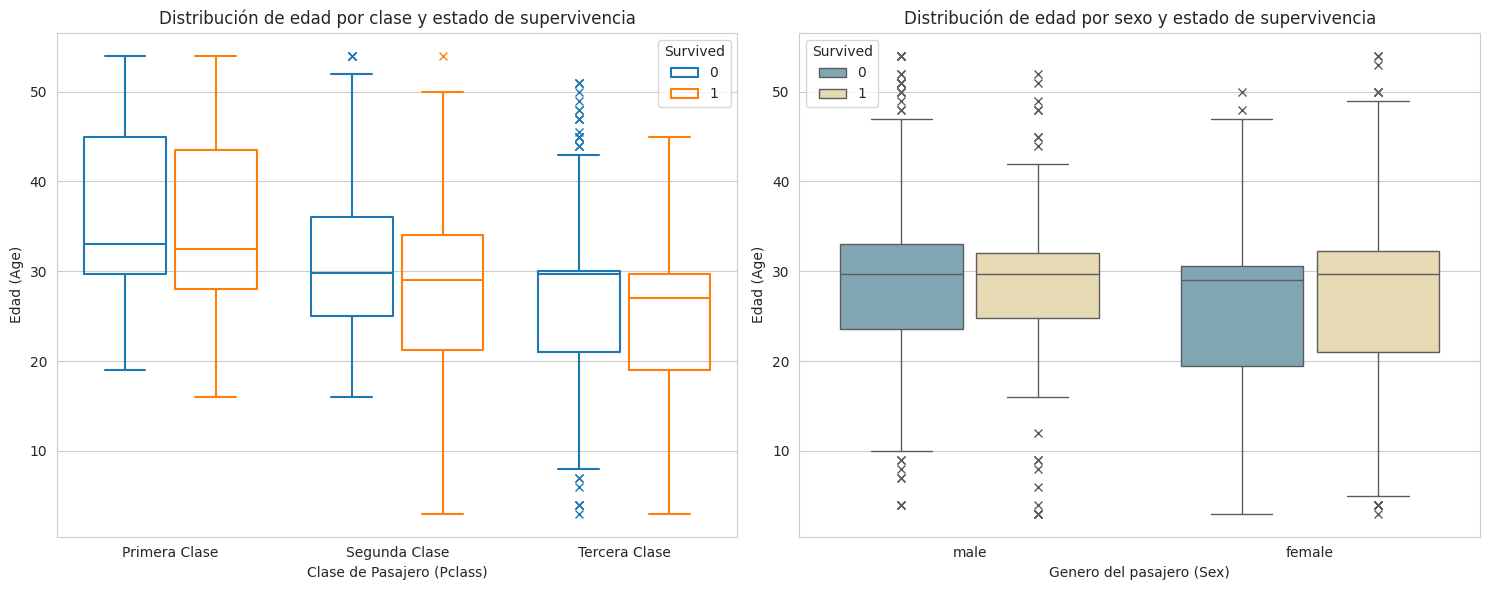

In [ ]:
fig, axs = plt.subplots(figsize=(15, 6), ncols=2, nrows=1)

sns.boxplot(data=df2, x="Pclass", y="Age", hue="Survived", flierprops={"marker": "x"}, fill=False, gap=.1, ax=axs[0])
axs[0].set_title('Distribución de edad por clase y estado de supervivencia')
axs[0].set_xlabel('Clase de Pasajero (Pclass)')
axs[0].set_ylabel('Edad (Age)')
axs[0].set_xticks([0, 1, 2])
axs[0].set_xticklabels(['Primera Clase', 'Segunda Clase', 'Tercera Clase'])

sns.boxplot(data=df2, x="Sex", y="Age", hue="Survived", flierprops={"marker": "x"}, palette='blend:#7AB,#EDA', gap=.1, ax=axs[1])
axs[1].set_title('Distribución de edad por sexo y estado de supervivencia')
axs[1].set_xlabel('Genero del pasajero (Sex)')
axs[1].set_ylabel('Edad (Age)')

plt.tight_layout()
plt.show()

En el primer grafico podemos ver la distribucion de edad por clase y estado de supervivencia, aqui podemos ver que la edad parece estar correlacionada con la clase del pasajero, siendo en general los pasajeros de primera clase mas viejos que los de segunda y a su ves los de segunda ligeramente mas mayores que los de tercera clase, por clases en general el promedio de edad entre los pasajeros que sobrevibieron y no sobrevivieron es similar, siendo solo un poco mayor la edad entre los no sobrebivientes de primera y segunda clase, en tercera clase por otro lado si se logra apreciar una mayor diferencia al promedio de los no sobrevibientes estar muy cerca de su Q3 y notarse claramente una diferencia entre el promedio de los sobrevibientes que es claramente menor.

El segundo grafico muestra la distribucion de edad por genero y estado de supervibencia, para los hombres podemos notar que los no sobrevibientes tienen un rango intercuartil de edades mas amplio que los sobrevientes, lo que nos indica que los hombres sobrevibientes se agrupaban en un rango de edades mas acotado, para las mujeres en cambio podemos ver que las no sobrevibientes presentan un rango intercuartil de edades ligeramente mas bajo que las sobrevibientes.

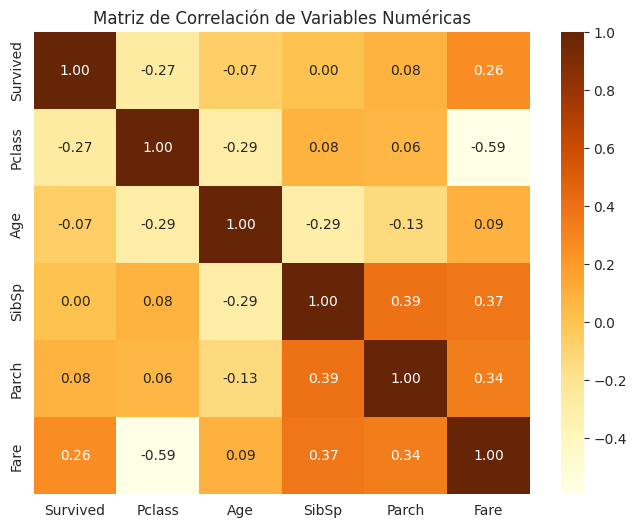

In [ ]:
correlation_matrix = df2.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='YlOrBr', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

las correlaciones mas claras que podemos apreciar en este grafico son:

Clase(PClass) - Tarifa(Fare): La correlacion mas alta, es una correlacion moderada negativa, mientras mas alta la tarifa mas se hacerca al 1 (osea primera clase)

Tarifa y cantidad de hermanos o conyuges: una correlacion baja positiva del 0,37, esto nos indica que en general mientras mayor la tarifa mayor es la cantidad de hermanos o conyuges


Tarifa y cantidad de hijos o padres: una correlacion baja positiva del 0,34, esto nos indica que en general mientras mayor la tarifa mayor es la cantidad de hijos o padres

Cantidad de hijos o padres y cantidad de hermanos o conyuges: una correlacion baja positiva del 0,39, esto nos indica que en general mientral mayor antidad de hijos o padres mayor es la cantidad de hermanos o conyuges

todo el resto de correlaciones es demaciado bajo como para considerar alguna relacion o influencia real

### Hallazgos de clave de análisis de datos
*   **Tasa de supervivencia:** La mayoría de los pasajeros no sobrevivieron, con 478 pasajeros (66.30%) que no sobrevivieron en comparación con 243 pasajeros (33.70%) que lo hicieron.
*   **Distribución de clase de pasajeros:** El conjunto de datos está muy sesgado hacia PCLASS 3, con 462 pasajeros (64.08%) en tercera clase, seguido de PCLASS 2 (164 pasajeros, 22.75%) y PCLASS 1 (95 pasajeros, 13.18%). Tanto la moda como la mediana para 'PCLASS' son 3.
*   **Distribucion de Genero:** Hay una distribución de género desequilibrada, con 490 pasajeros masculinos (67.96%) y 231 pasajeras (32.04%). La moda para 'sexo' es 'masculino'.
*   **Distribuccion de edad:** La edad promedio es de aproximadamente 28.48, con una mediana y un modo alrededor de 29.70. La distribución de edad es ligeramente sesgada a la derecha, con un rango de 3 a 54 y algunos valores atípicos a edades más altas.
*   **Hermanos / Conyuges a bordo (SibSp):** La mayoría de los pasajeros viajaron solo o con solo un hermano o cónyuge. La media 'SIBSP' es 0.41, mientras que la mediana y la moda son 0. La distribución es muy sesgada con valores atípicos de hasta 5.
*   **Padres / Hijos a bordo (Parch):** La mayoría de los pasajeros viajaron sin padres o hijos. La media 'Parch' es 0.32, con la mediana y el modo de ser 0. La distribución está muy sesgada hacia 0, con valores atípicos de hasta 6.
*   **Distribución de tarifas:** La distribución de tarifas es muy sesgada a la derecha, con una media de `$17.39`, una mediana de `$12.28` y una moda de `$8.05`. La mayoría de los pasajeros pagaron tarifas más bajas, y hay valores atípicos con valores de tarifas más altos (hasta `$65.00`).
*   **Puerto de Embarque:** El puerto de embarque más común fue Southampton (s), que representa aproximadamente el 75.6% de los pasajeros. Cherburgo (C) fue el segundo más frecuente (aproximadamente 14.6%), seguido de Queenstown (Q) (aproximadamente 9.8%).

# Arbol de decision

In [ ]:
df_arbol = df2.copy()
df_arbol.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,clase
0,0,3,male,22.000000,1,0,7.2500,S,Tercera Clase
2,1,3,female,26.000000,0,0,7.9250,S,Tercera Clase
3,1,1,female,35.000000,1,0,53.1000,S,Primera Clase
4,0,3,male,35.000000,0,0,8.0500,S,Tercera Clase
5,0,3,male,29.699118,0,0,8.4583,Q,Tercera Clase


In [ ]:
df_arbol = pd.get_dummies(data=df_arbol,drop_first=True,dtype=int)
df_arbol.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,clase_Segunda Clase,clase_Tercera Clase
0,0,3,22.000000,1,0,7.2500,1,0,1,0,1
2,1,3,26.000000,0,0,7.9250,0,0,1,0,1
3,1,1,35.000000,1,0,53.1000,0,0,1,0,0
4,0,3,35.000000,0,0,8.0500,1,0,1,0,1
5,0,3,29.699118,0,0,8.4583,1,1,0,0,1


In [ ]:
variables_explicativas = df_arbol.drop(columns="Survived")
variable_objetivo = df_arbol.Survived

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=3)
model.fit(X=variables_explicativas, y=variable_objetivo)
DecisionTreeClassifier(max_depth=3)

DecisionTreeClassifier(max_depth=3)

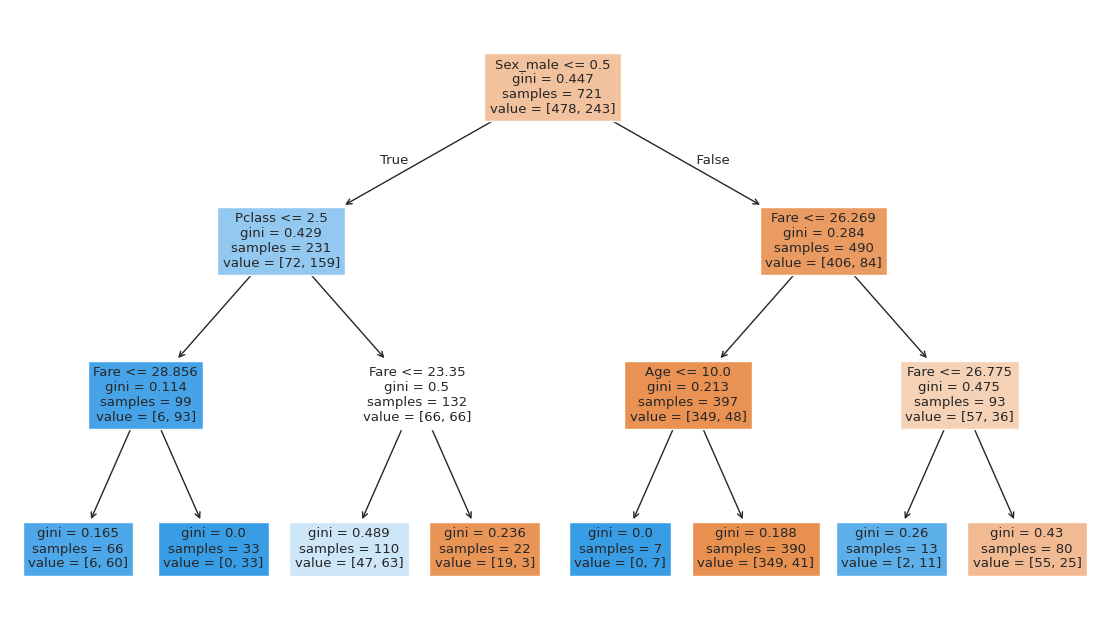

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(14,8))
plot_tree(decision_tree=model,feature_names=variables_explicativas.columns, filled=True);

## Prediccion

In [ ]:
a=variables_explicativas.sample()
a

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,clase_Segunda Clase,clase_Tercera Clase
538,3,29.699118,0,0,14.5,1,0,1,0,1


In [ ]:
model.predict_proba(a)

array([[0.89487179, 0.10512821]])

In [ ]:
model.predict(variables_explicativas)

array([0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,

In [ ]:
model.predict(variables_explicativas).shape

(721,)

In [ ]:
y_predict=model.predict(variables_explicativas)

## Interpretar Modelo

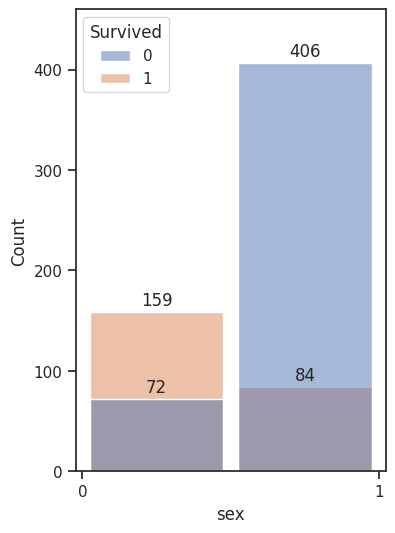

In [ ]:
sns.set_theme(style="ticks")
plt.figure(figsize=(4, 6))
ax = sns.histplot(data=df_arbol, x='Sex_male', hue='Survived',binwidth=0.5, shrink=0.9)
plt.xticks([0, 1]) # Add this line to set the ticks to 0 and 1
for container in ax.containers:
    ax.bar_label(container, padding=2, fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
plt.ylim(0, df_arbol['Sex_male'].value_counts().max() - 30)
plt.xlabel("sex")
plt.show()

## Como de Bueno es el Modelo

In [ ]:
df_arbol['pred']= y_predict
df_arbol.sample(10)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,clase_Segunda Clase,clase_Tercera Clase,pred
408,0,3,21.000000,0,0,7.7750,1,0,1,0,1,0
17,1,2,29.699118,0,0,13.0000,1,0,1,1,0,0
361,0,2,29.000000,1,0,27.7208,1,0,0,1,0,0
443,1,2,28.000000,0,0,13.0000,0,0,1,1,0,1
173,0,3,21.000000,0,0,7.9250,1,0,1,0,1,0
738,0,3,29.699118,0,0,7.8958,1,0,1,0,1,0
278,0,3,7.000000,4,1,29.1250,1,1,0,0,1,0
2,1,3,26.000000,0,0,7.9250,0,0,1,0,1,1
371,0,3,18.000000,1,0,6.4958,1,0,1,0,1,0
104,0,3,37.000000,2,0,7.9250,1,0,1,0,1,0


In [ ]:
df_arbol.sample(10)[["Survived","pred"]]

,Survived,pred
524,0,0
93,0,0
564,0,1
794,0,0
676,0,0
37,0,0
165,1,1
552,0,0
590,0,0
862,1,1


In [ ]:
df_arbol['Survived']==df_arbol['pred']

,0
0,True
2,True
3,True
4,True
5,True
...,...
886,True
887,True
888,True
889,False


In [ ]:
accuracy_dt = (df_arbol['Survived']==df_arbol['pred']).sum()/len(df_arbol)
print(accuracy_dt)

0.8280166435506241


In [ ]:
(df_arbol['Survived']==df_arbol['pred']).sum()/721

np.float64(0.8280166435506241)

Finalmente podemos decir que nuestro modelo es tiene un 82% de esactitud

# Random forest

In [ ]:
df_r_forest = df2.copy()
df_r_forest.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,clase
0,0,3,male,22.000000,1,0,7.2500,S,Tercera Clase
2,1,3,female,26.000000,0,0,7.9250,S,Tercera Clase
3,1,1,female,35.000000,1,0,53.1000,S,Primera Clase
4,0,3,male,35.000000,0,0,8.0500,S,Tercera Clase
5,0,3,male,29.699118,0,0,8.4583,Q,Tercera Clase


In [ ]:
df_r_forest = pd.get_dummies(data=df_r_forest, drop_first=True, dtype=int)
df_r_forest.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,clase_Segunda Clase,clase_Tercera Clase
0,0,3,22.000000,1,0,7.2500,1,0,1,0,1
2,1,3,26.000000,0,0,7.9250,0,0,1,0,1
3,1,1,35.000000,1,0,53.1000,0,0,1,0,0
4,0,3,35.000000,0,0,8.0500,1,0,1,0,1
5,0,3,29.699118,0,0,8.4583,1,1,0,0,1


In [ ]:
# Definir variables explicativas (X) y variable objetivo (y)
X = df_r_forest.drop(columns="Survived")
y = df_r_forest.Survived

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X, y)

RandomForestClassifier(random_state=42)

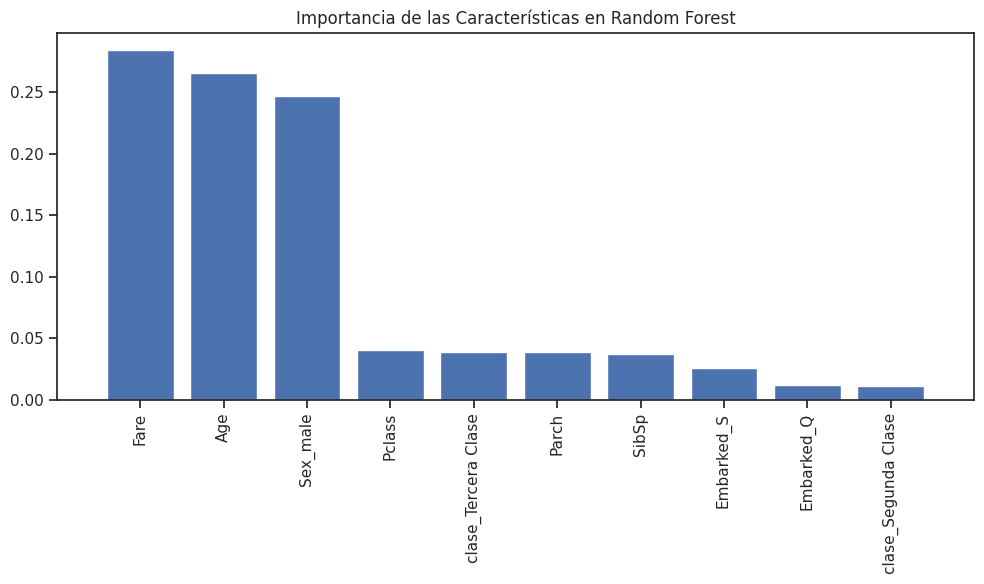

In [ ]:
# Visualizar la importancia de las características en el Random Forest
importances = model_rf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Importancia de las Características en Random Forest")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), features[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()

## Prediccion

In [ ]:
pred=X.sample()
pred

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,clase_Segunda Clase,clase_Tercera Clase
656,3,29.699118,0,0,7.8958,1,0,1,0,1


In [ ]:
model_rf.predict_proba(X.sample())

array([[0.07, 0.93]])

In [ ]:
model_rf.predict(X)

array([0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,

In [ ]:
model_rf.predict(X).shape

(721,)

In [ ]:
y_predict_rf=model_rf.predict(X)

## Interpretar Modelo

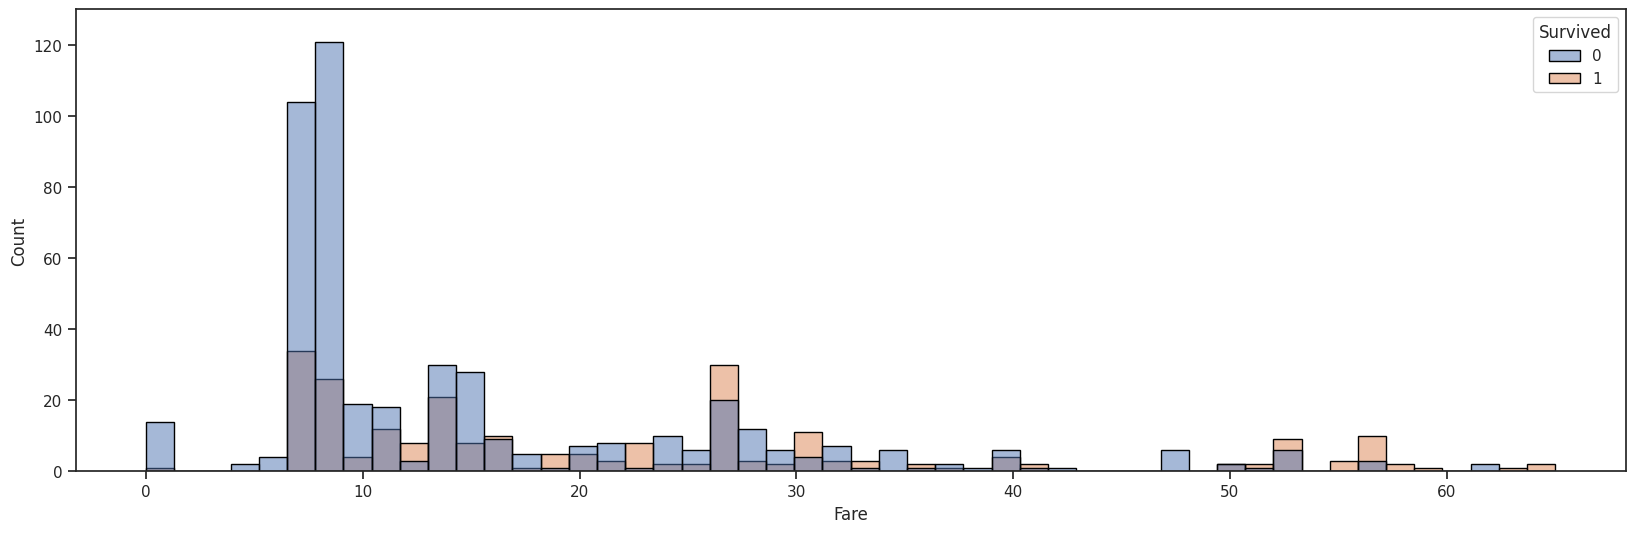

In [ ]:
plt.figure(figsize=(20, 6))
sns.histplot(x=df_r_forest.Fare, hue=df_r_forest.Survived,bins=50,edgecolor='black')
plt.ylim(0, df_r_forest['Fare'].value_counts().max()*3.1)
plt.show()

## Como de bueno es el modelo

In [ ]:
df_r_forest['pred']= y_predict_rf
df_r_forest.sample(10)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,clase_Segunda Clase,clase_Tercera Clase,pred
623,0,3,21.000000,0,0,7.8542,1,0,1,0,1,0
464,0,3,29.699118,0,0,8.0500,1,0,1,0,1,0
734,0,2,23.000000,0,0,13.0000,1,0,1,1,0,0
320,0,3,22.000000,0,0,7.2500,1,0,1,0,1,0
454,0,3,29.699118,0,0,8.0500,1,0,1,0,1,0
774,1,2,54.000000,1,3,23.0000,0,0,1,1,0,1
561,0,3,40.000000,0,0,7.8958,1,0,1,0,1,0
869,1,3,4.000000,1,1,11.1333,1,0,1,0,1,1
871,1,1,47.000000,1,1,52.5542,0,0,1,0,0,1
254,0,3,41.000000,0,2,20.2125,0,0,1,0,1,0


In [ ]:
df_r_forest.sample(10)[["Survived","pred"]]

,Survived,pred
309,1,1
836,0,0
511,0,0
764,0,0
577,1,1
328,1,1
810,0,0
648,0,0
766,0,0
589,0,0


In [ ]:
df_r_forest['Survived']==df_r_forest['pred']

,0
0,True
2,True
3,True
4,True
5,True
...,...
886,True
887,True
888,True
889,True


In [ ]:
accuracy_rf = (df_r_forest['Survived']==df_r_forest['pred']).sum()/len(df_r_forest)
print(accuracy_rf)

0.9778085991678225


In [ ]:
(df_r_forest['Survived']==df_r_forest['pred']).sum()/721

np.float64(0.9778085991678225)

Finalmente podemos decir que nuestro modelo es tiene un 97% de esactitud

# Naive Bayes

In [ ]:
df_naivBy = df2.copy()
df_naivBy.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,clase
0,0,3,male,22.000000,1,0,7.2500,S,Tercera Clase
2,1,3,female,26.000000,0,0,7.9250,S,Tercera Clase
3,1,1,female,35.000000,1,0,53.1000,S,Primera Clase
4,0,3,male,35.000000,0,0,8.0500,S,Tercera Clase
5,0,3,male,29.699118,0,0,8.4583,Q,Tercera Clase


In [ ]:
df_naivBy = pd.get_dummies(data=df_naivBy, drop_first=True, dtype=int)
df_naivBy.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,clase_Segunda Clase,clase_Tercera Clase
0,0,3,22.000000,1,0,7.2500,1,0,1,0,1
2,1,3,26.000000,0,0,7.9250,0,0,1,0,1
3,1,1,35.000000,1,0,53.1000,0,0,1,0,0
4,0,3,35.000000,0,0,8.0500,1,0,1,0,1
5,0,3,29.699118,0,0,8.4583,1,1,0,0,1


In [ ]:
X = df_naivBy.drop(columns="Survived")
y = df_naivBy.Survived

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Inicializar y entrenar el modelo Naive Bayes Gaussiano
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

GaussianNB()

## Prediccion

In [ ]:
# Predecir en el conjunto de prueba
y_pred_nb = model_nb.predict(X_test)

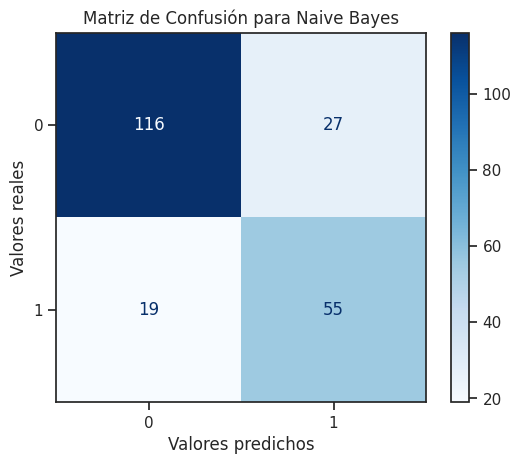

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generar la matriz de confusión
cm = confusion_matrix(y_test, y_pred_nb, labels=model_nb.classes_)

# Visualizar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_nb.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión para Naive Bayes')
plt.ylabel('Valores reales')
plt.xlabel('Valores predichos')
plt.show()

Aqui en la Matriz de confusion podemos ver la diferencia entre los valores reales y los valores predichos.
*   El modelo en el caso de los pasajeros no sobrevibiente '0' acerto un 81.1% de las veces
*   El modelo en el caso de los pasajeros sobrevibientes '1' acerto un 74.3% de las veces



## Como de bueno es el modelo

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
# Evaluar el modelo
accuracy_nb = accuracy_score(y_test, y_pred_nb)
f1 = f1_score(y_pred_nb, y_test, average="weighted")

print("Accuracy:", accuracy_nb)
print("F1 Score:", f1)

Accuracy: 0.7880184331797235
F1 Score: 0.7856331028760827


El modelo tiene una precision de un 78%

# Comparacion de los modelos

In [ ]:
model_comparison = {
    'Model': ['Decision Tree', 'Random Forest', 'Naive Bayes'],
    'Accuracy': [accuracy_dt, accuracy_rf, accuracy_nb]
}

df_comparison = pd.DataFrame(model_comparison)
display(df_comparison)

,Model,Accuracy
0,Decision Tree,0.828017
1,Random Forest,0.977809
2,Naive Bayes,0.788018
